# Notebook 3 v2 — Leakage-safe ML, controls, sensitivity analysis, and Q1-style figure panels

This notebook replaces the previous Notebook 3.

The previous output showed near-perfect performance because target-construction variables such as `has_exact_compound_in_title` leaked the literature-derived label into the predictors. This revised notebook fixes that problem.

## What is fixed

1. **Target leakage removed from main models**
   - Excludes all PubMed/literature/title/curation/target-construction fields from predictors.
   - The leaky variables are retained only for a separate diagnostic demonstration.

2. **Pathway features restored**
   - `pathway_support_score` and `PWY_*` features are retained as valid biological predictors.
   - The previous broad exclusion of `"path"` is removed.

3. **Biologically meaningful feature blocks**
   - coverage/data-availability controls,
   - environment/spatial predictors,
   - genetic availability predictors,
   - biosynthetic pathway predictors,
   - combined leakage-safe predictors.

4. **Grouped validation retained**
   - leave-one-taxon-out,
   - leave-one-compound-class-out,
   - leave-one-compound-out,
   - occurrence-level spatial sensitivity only as secondary analysis.

5. **Null controls added**
   - majority-class baseline,
   - grouped label-permutation control,
   - pseudo-negative/positive-unlabeled sensitivity.

6. **Publishable interpretation**
   - Reports leakage-safe results as exploratory/prioritization evidence.
   - Does not claim causal environmental effects or confirmed metabolite concentrations.

## Primary modelling unit

The primary table is one row per:

> **taxon × compound**

not occurrence-expanded rows.

Occurrence-level data are used only for spatial sensitivity.

## Main target

Current target is **open-data medicinal compound evidence**, not measured metabolite concentration.

- Binary target: `target_label_for_open_data_classifier`
- Ordinal target: `target_evidence_score`

Rows with score 0 are background/pseudo-negatives, not confirmed biological absences.

## 0. Recommended environment

```bash
conda create -n medicinal-ml-v2 python=3.11 -y
conda activate medicinal-ml-v2

conda install -c conda-forge pandas numpy matplotlib scikit-learn scipy networkx pyarrow pyyaml -y
pip install shap
```

SHAP is optional. The notebook always computes permutation importance.

In [6]:
# ============================================================
# 0. Imports
# ============================================================

import os
import re
import json
import math
import pathlib
import zipfile
import hashlib
import warnings
import datetime as dt
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

try:
    from scipy.stats import spearmanr
    from scipy.cluster.hierarchy import linkage, leaves_list
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except Exception:
    NETWORKX_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 220)

## 1. Configuration

Set `input_dirs` to the folder containing either:

1. the Notebook 3 readiness package, or
2. the raw Notebook 2 outputs.

The preferred input is:

`notebook3_primary_taxon_compound_table.tsv`

Fallback:

`taxon_compound_feature_matrix_for_relationships.tsv`

In [7]:
# ============================================================
# 1. Configuration
# ============================================================

CONFIG = {
    "project_dir": "notebook3_v2_leakage_safe_outputs",

    "input_dirs": [
        ".",
        "/content",
        "/mnt/data",
        "/content/notebook3_readiness_from_notebook2_outputs",
        "/content/notebook2_environment_target_outputs",
        "/content/notebook2_environment_target_outputs/derived",
        "/mnt/data/notebook3_readiness_from_notebook2_outputs",
        "/mnt/data/notebook2_environment_target_outputs",
    ],

    "binary_target_col": "target_label_for_open_data_classifier",
    "ordinal_target_col": "target_evidence_score",

    # Exact leakage columns known from Notebook 2.
    "explicit_leakage_columns": [
        "has_exact_compound_in_title",
        "has_literature_support",
        "has_accumulation_or_pathway_terms",
        "n_supporting_pubmed_records",
        "n_recent_pubmed_records_2015plus",
        "is_curated_positive_pair",
        "target_type_recommendation",
        "target_confidence_initial",
        "target_evidence_class",
        "target_warning",
        "pseudo_negative_flag",
        "target_label_for_open_data_classifier",
        "target_evidence_score",
    ],

    # Substrings that indicate target-construction leakage.
    "leakage_substrings": [
        "pubmed",
        "literature",
        "curated",
        "exact_compound",
        "evidence_class",
        "target_type",
        "target_confidence",
        "pseudo_negative",
        "target_warning",
        "label_for_open_data",
        "supporting_paper",
        "supporting_pubmed",
    ],

    # Identifier/categorical fields excluded from numeric modelling.
    # Do NOT include generic "path" because it wrongly excludes pathway features.
    "identifier_or_metadata_substrings": [
        "taxon_id",
        "compound_id",
        "row_id",
        "gbif_key",
        "source_group_id",
        "spatial_group_id",
        "taxonomic_group_id",
        "compound_group_id",
        "spatial_block_id",
        "scientific_name",
        "compound_name",
        "family",
        "rank",
        "ml_role",
        "source_path",
        "file_path",
        "absolute_path",
        "doi",
        "pmid",
        "inchikey",
        "smiles",
        "formula",
        "status",
        "warning",
    ],

    # Curated feature block definitions. These are leakage-safe by construction.
    "feature_block_patterns": {
        "coverage_control": [
            "n_occurrences",
            "n_occurrence_records",
            "n_spatial_blocks",
            "coordinate_uncertainty",
        ],
        "environment_spatial": [
            "decimal_latitude",
            "decimal_longitude",
            "abs_latitude",
            "latitude_squared",
            "longitude_squared",
            "sin_latitude",
            "cos_latitude",
            "sin_longitude",
            "cos_longitude",
            "mean_abs_latitude",
            "lat_range",
            "lon_range",
            "worldclim_",
            "soilgrids_",
        ],
        "genetic_availability": [
            "genetic_data_availability_score",
            "n_public_barcode_records",
            "n_chloroplast_plastid_records",
            "n_public_genome_assemblies",
            "n_ena_rnaseq_runs",
            "n_ena_wgs_runs",
            "n_ena_amplicon_runs",
            "n_pathways_with_specific_candidates",
        ],
        "pathway_biosynthetic": [
            "pathway_support_score",
            "sum_pathway_potential_score",
            "max_pathway_potential_score",
            "PWY_",
            "pathway_potential_score",
            "n_candidate_protein_hits",
            "n_specific_candidate_hits",
            "n_broad_family_hits",
            "max_specificity_score",
        ],
    },

    "primary_performance_metric": "balanced_accuracy",
    "random_seed": 42,
    "n_label_permutations": 200,
    "n_pu_repeats": 100,
    "pu_background_ratios": [0.25, 0.5, 1.0],
    "min_valid_group_folds": 3,

    # Figures.
    "figure_dpi": 300,
    "save_pdf": True,
}

PROJECT = pathlib.Path(CONFIG["project_dir"]).resolve()
DIRS = {
    "derived": PROJECT / "derived",
    "figures": PROJECT / "figures",
    "tables": PROJECT / "tables",
    "models": PROJECT / "models",
    "logs": PROJECT / "logs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
CONFIG["run_id"] = RUN_ID
CONFIG["created_utc"] = dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds")

with open(PROJECT / "notebook3_v2_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

PROJECT

PosixPath('/content/notebook3_v2_leakage_safe_outputs')

In [8]:
# ============================================================
# 2. Utility functions
# ============================================================

def safe_name(x: str, max_len: int = 160) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")[:max_len]

def sha256_file(path: pathlib.Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def find_input_file(filename: str, required=True) -> Optional[pathlib.Path]:
    candidates = []
    for d in CONFIG["input_dirs"]:
        d = pathlib.Path(d)
        candidates.append(d / filename)
        if d.exists() and d.is_dir():
            candidates.extend(d.rglob(filename))
    existing = sorted(set([p for p in candidates if p.exists()]), key=lambda p: (len(str(p)), str(p)))
    if not existing:
        if required:
            raise FileNotFoundError(f"Could not find {filename}. Add its folder to CONFIG['input_dirs'].")
        return None
    return existing[0]

def load_tsv_any(possible_filenames: List[str], required=True) -> pd.DataFrame:
    for filename in possible_filenames:
        path = find_input_file(filename, required=False)
        if path is not None:
            df = pd.read_csv(path, sep="\t", dtype=str, low_memory=False)
            df.attrs["source_path"] = str(path)
            print(f"Loaded {filename}: {df.shape} from {path}")
            return df
    if required:
        raise FileNotFoundError(f"None of these files were found: {possible_filenames}")
    print(f"Optional files not found: {possible_filenames}")
    return pd.DataFrame()

def write_table(df: pd.DataFrame, path_stem: pathlib.Path) -> Dict[str, str]:
    path_stem.parent.mkdir(parents=True, exist_ok=True)
    tsv = path_stem.with_suffix(".tsv")
    df.to_csv(tsv, sep="\t", index=False)
    out = {"tsv": str(tsv)}
    try:
        pq = path_stem.with_suffix(".parquet")
        df.to_parquet(pq, index=False)
        out["parquet"] = str(pq)
    except Exception as e:
        print(f"Parquet skipped for {path_stem.name}: {e}")
    return out

def save_figure(fig, name: str):
    png_path = DIRS["figures"] / f"{safe_name(name)}.png"
    fig.savefig(png_path, dpi=CONFIG["figure_dpi"], bbox_inches="tight")
    outputs = [str(png_path)]
    if CONFIG["save_pdf"]:
        pdf_path = DIRS["figures"] / f"{safe_name(name)}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        outputs.append(str(pdf_path))
    print("Saved:", outputs)
    return outputs

def add_panel_label(ax, label: str):
    ax.text(-0.10, 1.08, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

def col_contains_any(col: str, patterns: List[str]) -> bool:
    c = str(col).lower()
    return any(str(p).lower() in c for p in patterns)

def as_numeric_df(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for c in cols:
        out[c] = pd.to_numeric(df[c], errors="coerce")
    return out

def safe_roc_auc(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def safe_average_precision(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan

def spearman_safe(x, y):
    try:
        x = pd.to_numeric(pd.Series(x), errors="coerce")
        y = pd.to_numeric(pd.Series(y), errors="coerce")
        ok = x.notna() & y.notna()
        if ok.sum() < 3 or x[ok].nunique() <= 1 or y[ok].nunique() <= 1:
            return np.nan
        return spearmanr(x[ok], y[ok]).correlation
    except Exception:
        return np.nan

def metric_ci(values):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        return pd.Series({"mean": np.nan, "std": np.nan, "n": 0, "ci_low": np.nan, "ci_high": np.nan})
    return pd.Series({
        "mean": values.mean(),
        "std": values.std(ddof=1) if len(values) > 1 else 0,
        "n": len(values),
        "ci_low": values.quantile(0.025),
        "ci_high": values.quantile(0.975),
    })

## 2. Load Notebook 2 / Notebook 3 readiness outputs

In [9]:
# ============================================================
# 3. Load data
# ============================================================

# Check if the input zip file exists and extract its contents
zip_path = pathlib.Path("/content/notebook3_readiness_from_notebook2_outputs.zip")
extract_dir = pathlib.Path("/content/notebook3_readiness_from_notebook2_outputs")

if zip_path.is_file() and not extract_dir.exists():
    print(f"Unzipping {zip_path.name} to {extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Unzipping complete.")
elif not zip_path.is_file():
    print(f"Warning: Zip file not found at {zip_path}. Assuming data is already present or will be downloaded.")
else:
    print(f"Directory {extract_dir} already exists. Skipping unzipping.")


primary_df = load_tsv_any([
    "notebook3_primary_taxon_compound_table.tsv",
    "taxon_compound_feature_matrix_for_relationships.tsv",
], required=True)

occurrence_sensitivity_df = load_tsv_any([
    "notebook3_occurrence_level_spatial_sensitivity_table.tsv",
    "taxon_occurrence_compound_ml_table.tsv",
], required=False)

validation_groups_df = load_tsv_any([
    "validation_group_table_for_notebook3.tsv",
], required=False)

# Prepare targets
if CONFIG["ordinal_target_col"] not in primary_df.columns:
    raise ValueError(f"Primary table must contain {CONFIG['ordinal_target_col']}.")

primary_df[CONFIG["ordinal_target_col"]] = pd.to_numeric(primary_df[CONFIG["ordinal_target_col"]], errors="coerce").fillna(0).astype(int)

if CONFIG["binary_target_col"] not in primary_df.columns:
    primary_df[CONFIG["binary_target_col"]] = (primary_df[CONFIG["ordinal_target_col"]] >= 2).astype(int)
else:
    primary_df[CONFIG["binary_target_col"]] = pd.to_numeric(primary_df[CONFIG["binary_target_col"]], errors="coerce").fillna(0).astype(int)

# Add stable row id
if "notebook3_primary_row_id" not in primary_df.columns:
    primary_df["notebook3_primary_row_id"] = ["TC_" + str(i).zfill(5) for i in range(len(primary_df))]

print("Primary table shape:", primary_df.shape)
print("Occurrence sensitivity table shape:", occurrence_sensitivity_df.shape)
display(primary_df.head())

Directory /content/notebook3_readiness_from_notebook2_outputs already exists. Skipping unzipping.
Loaded notebook3_primary_taxon_compound_table.tsv: (60, 89) from notebook3_readiness_from_notebook2_outputs/notebook3_primary_taxon_compound_table.tsv
Loaded notebook3_occurrence_level_spatial_sensitivity_table.tsv: (70350, 112) from notebook3_readiness_from_notebook2_outputs/notebook3_occurrence_level_spatial_sensitivity_table.tsv
Optional files not found: ['validation_group_table_for_notebook3.tsv']
Primary table shape: (60, 90)
Occurrence sensitivity table shape: (70350, 112)


,taxon_id,compound_id,taxon_name,family,rank,priority,ml_role_taxon,open_data_ml_readiness,compound_name,compound_class,compound_record_type,record_type,compound_dictionary_status,target_evidence_class,target_type_recommendation,target_confidence_initial,target_warning,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,gbif_match_confidence,gbif_filter_uncertainty_threshold_m,abs_latitude,latitude_squared,longitude_squared,sin_latitude,cos_latitude,sin_longitude,cos_longitude,coordinate_uncertainty_missing,coordinate_uncertainty_log1p,genetic_data_availability_score,pathway_support_score,n_public_barcode_records,n_chloroplast_plastid_records,n_public_genome_assemblies,n_ena_rnaseq_runs,n_pathways_with_specific_candidates,sum_pathway_potential_score,PWY_ALKALOID__n_candidate_protein_hits,PWY_HYPERICIN__n_candidate_protein_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_candidate_protein_hits,PWY_SALIDROSIDE__n_candidate_protein_hits,PWY_TERPENOID__n_candidate_protein_hits,PWY_ALKALOID__n_specific_candidate_hits,PWY_HYPERICIN__n_specific_candidate_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_specific_candidate_hits,PWY_SALIDROSIDE__n_specific_candidate_hits,PWY_TERPENOID__n_specific_candidate_hits,PWY_ALKALOID__n_broad_family_hits,PWY_HYPERICIN__n_broad_family_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_broad_family_hits,PWY_SALIDROSIDE__n_broad_family_hits,PWY_TERPENOID__n_broad_family_hits,PWY_ALKALOID__max_specificity_score,PWY_HYPERICIN__max_specificity_score,PWY_PHENYLPROPANOID_FLAVONOID__max_specificity_score,PWY_SALIDROSIDE__max_specificity_score,PWY_TERPENOID__max_specificity_score,PWY_ALKALOID__pathway_potential_score,PWY_HYPERICIN__pathway_potential_score,PWY_PHENYLPROPANOID_FLAVONOID__pathway_potential_score,PWY_SALIDROSIDE__pathway_potential_score,PWY_TERPENOID__pathway_potential_score,n_supporting_pubmed_records,n_recent_pubmed_records_2015plus,has_literature_support,has_accumulation_or_pathway_terms,has_exact_compound_in_title,is_curated_positive_pair,target_evidence_score,target_label_for_open_data_classifier,pseudo_negative_flag,molecular_weight,n_occurrence_rows,n_unique_gbif_records,n_spatial_blocks,n_countries,lat_min,lat_max,lon_min,lon_max,lat_range,lon_range,taxonomic_group_id,compound_group_id,notebook3_primary_use,warning,notebook3_primary_row_id
0,TAX_ARTEMISIA_ANNUA,CMP_ALKALOIDS,Artemisia annua,Asteraceae,species,positive_control,candidate_taxon,core,alkaloids,alkaloids,compound_class,compound_class,compound_class_no_pubchem_resolution_expected,literature_supported,candidate_for_quantitative_curation,moderate,NaN,38.79810506677938,1.7179408030431107,14.0,2025.0,97,10000,43.28773572442942,1909.217740041616,3975.3555398829935,0.6084241339539936,0.7239133269983102,-0.024935895040571893,0.5163575980026205,1,2.6754651912577074,6.0,9.5,358,44,3,214,1,51.0,917,1151,168,87,979,0,0,0,0,13,917,1151,168,87,966,2.0,2.0,0.0,0.0,2.0,7.0,7.0,5.0,5.0,27.0,6,5,1,1,1,0,2,1,0,NaN,1183,1183,79,40,-37.378759,56.332128,-123.058404,174.773499,93.710887,297.831903,Asteraceae__TAX_ARTEMISIA_ANNUA,alkaloids,taxon_compound_baseline,One row per taxon-compound. Use grouped CV; no...,TC_00000
1,TAX_ARTEMISIA_ANNUA,CMP_ARTEMISININ,Artemisia annua,Asteraceae,species,positive_control,candidate_taxon,core,artemisinin,sesquiterpene lactone,molecule,molecule,molecule_pubchem_resolved,curated_strong_positive,candidate_for_quantitative_curation,moderate,NaN,38.79810506677938,1.7179408030431107,14.0,2025.0,97,10000,43.28773572442942,1909.217740041616,3975.3555398829935,0.6084241339539936,0.7239133269983102,-0.024935895040571893,0.5163575980026205,1,2.6754651912577074,6.0,9.5,358,44,3,214,1,51.0,917,1151,168,87,979,0,0,0,0,13,917,1151,168,87,966,2.0,2.0,0.0,0.0,2.0,7.0,7.0,5.0,5.0,27.0,100,100,1,1,1,1,3,1,0,282.33,1183,1183,79,40,-37.378759,56.332128,-123.058404,174.773499,93.710887,297.831903,Asteraceae__TAX_ARTEMISIA_ANNUA,sesquiterpene lactone,taxon_compound_baseline,One row per taxon-compound. Use grouped CV; no...,TC_00001
2,TAX_ARTEMISIA_

## 3. QC and corrected leakage audit

This section explicitly separates:

1. **leakage-safe predictors** used for publishable models;
2. **leaky diagnostic predictors** used only to demonstrate why the previous Notebook 3 overperformed.

The main correction is that `pathway_support_score` and other pathway variables are retained.

In [10]:
# ============================================================
# 4. Input QC and target distribution
# ============================================================

qc_rows = [
    {"metric": "primary_rows_taxon_compound", "value": len(primary_df)},
    {"metric": "unique_taxa", "value": primary_df["taxon_id"].nunique() if "taxon_id" in primary_df.columns else np.nan},
    {"metric": "unique_compounds", "value": primary_df["compound_id"].nunique() if "compound_id" in primary_df.columns else np.nan},
    {"metric": "unique_compound_classes", "value": primary_df["compound_class"].nunique() if "compound_class" in primary_df.columns else np.nan},
    {"metric": "binary_positive_rows", "value": int(primary_df[CONFIG["binary_target_col"]].sum())},
    {"metric": "binary_background_rows", "value": int((primary_df[CONFIG["binary_target_col"]] == 0).sum())},
    {"metric": "ordinal_classes", "value": ",".join(map(str, sorted(primary_df[CONFIG["ordinal_target_col"]].unique())))},
    {"metric": "occurrence_sensitivity_rows", "value": len(occurrence_sensitivity_df)},
]
qc_df = pd.DataFrame(qc_rows)
write_table(qc_df, DIRS["derived"] / "input_qc_summary_v2")
display(qc_df)

target_distribution_df = (
    primary_df.groupby([CONFIG["ordinal_target_col"], CONFIG["binary_target_col"]])
    .size()
    .reset_index(name="n_rows")
)
write_table(target_distribution_df, DIRS["derived"] / "target_distribution_v2")
display(target_distribution_df)

Parquet skipped for input_qc_summary_v2: ("Could not convert '0,1,2,3' with type str: tried to convert to int64", 'Conversion failed for column value with type object')


,metric,value
0,primary_rows_taxon_compound,60
1,unique_taxa,6
2,unique_compounds,10
3,unique_compound_classes,10
4,binary_positive_rows,27
5,binary_background_rows,33
6,ordinal_classes,"0,1,2,3"
7,occurrence_sensitivity_rows,70350


,target_evidence_score,target_label_for_open_data_classifier,n_rows
0,0,0,19
1,1,0,14
2,2,1,17
3,3,1,10


In [11]:
# ============================================================
# 5. Leakage-safe predictor selection
# ============================================================

numeric_convertible_cols = []
for c in primary_df.columns:
    if c in [CONFIG["binary_target_col"], CONFIG["ordinal_target_col"]]:
        continue
    vals = pd.to_numeric(primary_df[c], errors="coerce")
    if vals.notna().sum() >= 3 and vals.nunique(dropna=True) > 1:
        numeric_convertible_cols.append(c)

audit_rows = []
safe_feature_cols = []
leaky_diagnostic_cols = []

for c in numeric_convertible_cols:
    reason = ""
    status = "included_safe_predictor"

    if c in CONFIG["explicit_leakage_columns"]:
        status = "excluded_leakage"
        reason = "explicit_leakage_column"
    elif col_contains_any(c, CONFIG["leakage_substrings"]):
        status = "excluded_leakage"
        reason = "leakage_substring"
    elif col_contains_any(c, CONFIG["identifier_or_metadata_substrings"]):
        status = "excluded_metadata_or_identifier"
        reason = "metadata_identifier_substring"

    if status == "included_safe_predictor":
        safe_feature_cols.append(c)
    elif status == "excluded_leakage":
        leaky_diagnostic_cols.append(c)

    audit_rows.append({
        "column": c,
        "status": status,
        "reason": reason,
    })

feature_audit_df = pd.DataFrame(audit_rows).sort_values(["status", "column"])
write_table(feature_audit_df, DIRS["derived"] / "feature_leakage_audit_v2")

print("Safe predictors:", len(safe_feature_cols))
print("Leaky diagnostic predictors:", len(leaky_diagnostic_cols))
display(feature_audit_df)

# Check key expected features
expected_key_features = ["pathway_support_score", "sum_pathway_potential_score", "genetic_data_availability_score"]
key_feature_check = pd.DataFrame([
    {"feature": f, "included_safe": f in safe_feature_cols, "present": f in primary_df.columns}
    for f in expected_key_features
])
write_table(key_feature_check, DIRS["derived"] / "key_feature_inclusion_check_v2")
display(key_feature_check)

X_safe_df = as_numeric_df(primary_df, safe_feature_cols)
y_bin = primary_df[CONFIG["binary_target_col"]].astype(int).values
y_ord = primary_df[CONFIG["ordinal_target_col"]].astype(int).values

group_taxon = primary_df["taxon_id"].astype(str).values if "taxon_id" in primary_df.columns else np.array(["all"] * len(primary_df))
group_compound_class = primary_df["compound_class"].astype(str).values if "compound_class" in primary_df.columns else primary_df.get("compound_id", pd.Series(["all"] * len(primary_df))).astype(str).values
group_compound = primary_df["compound_id"].astype(str).values if "compound_id" in primary_df.columns else np.array(["all"] * len(primary_df))

write_table(pd.DataFrame({"feature": safe_feature_cols}), DIRS["derived"] / "safe_predictor_features_v2")
write_table(pd.DataFrame({"feature": leaky_diagnostic_cols}), DIRS["derived"] / "leaky_diagnostic_features_v2")

Safe predictors: 49
Leaky diagnostic predictors: 7


,column,status,reason
46,has_accumulation_or_pathway_terms,excluded_leakage,explicit_leakage_column
47,has_exact_compound_in_title,excluded_leakage,explicit_leakage_column
45,has_literature_support,excluded_leakage,explicit_leakage_column
48,is_curated_positive_pair,excluded_leakage,explicit_leakage_column
44,n_recent_pubmed_records_2015plus,excluded_leakage,explicit_leakage_column
...,...,...,...
52,n_unique_gbif_records,included_safe_predictor,
12,pathway_support_score,included_safe_predictor,
7,sin_latitude,included_safe_predictor,
9,sin_longitude,included_safe_predictor,


,feature,included_safe,present
0,pathway_support_score,True,True
1,sum_pathway_potential_score,True,True
2,genetic_data_availability_score,False,True


{'tsv': '/content/notebook3_v2_leakage_safe_outputs/derived/leaky_diagnostic_features_v2.tsv',
 'parquet': '/content/notebook3_v2_leakage_safe_outputs/derived/leaky_diagnostic_features_v2.parquet'}

## 4. Feature blocks

The notebook compares leakage-safe feature blocks:

- `coverage_control`
- `environment_spatial`
- `genetic_availability`
- `pathway_biosynthetic`
- `genetic_plus_pathway`
- `environment_plus_genetic_pathway`
- `combined_safe`

The purpose is to test whether biological pathway/genetic information adds value beyond data-coverage and spatial proxies.

In [12]:
# ============================================================
# 6. Define leakage-safe feature blocks
# ============================================================

def select_features_by_patterns(feature_cols, patterns):
    selected = []
    for c in feature_cols:
        if col_contains_any(c, patterns):
            selected.append(c)
    return selected

feature_blocks = {}
for block, patterns in CONFIG["feature_block_patterns"].items():
    cols = select_features_by_patterns(safe_feature_cols, patterns)
    if cols:
        feature_blocks[block] = cols

# Composite biological blocks
genetic_cols = feature_blocks.get("genetic_availability", [])
pathway_cols = feature_blocks.get("pathway_biosynthetic", [])
environment_cols = feature_blocks.get("environment_spatial", [])
coverage_cols = feature_blocks.get("coverage_control", [])

if genetic_cols or pathway_cols:
    feature_blocks["genetic_plus_pathway"] = sorted(set(genetic_cols + pathway_cols))
if environment_cols or genetic_cols or pathway_cols:
    feature_blocks["environment_plus_genetic_pathway"] = sorted(set(environment_cols + genetic_cols + pathway_cols))

feature_blocks["combined_safe"] = safe_feature_cols

feature_block_summary_df = pd.DataFrame([
    {"feature_block": block, "n_features": len(cols), "features": ";".join(cols)}
    for block, cols in feature_blocks.items()
])
write_table(feature_block_summary_df, DIRS["derived"] / "feature_block_summary_v2")
display(feature_block_summary_df)

,feature_block,n_features,features
0,coverage_control,3,coordinate_uncertainty_m;coordinate_uncertaint...
1,environment_spatial,11,decimal_latitude;decimal_longitude;abs_latitud...
2,genetic_availability,5,n_public_barcode_records;n_chloroplast_plastid...
3,pathway_biosynthetic,21,pathway_support_score;sum_pathway_potential_sc...
4,genetic_plus_pathway,26,PWY_ALKALOID__max_specificity_score;PWY_ALKALO...
5,environment_plus_genetic_pathway,37,PWY_ALKALOID__max_specificity_score;PWY_ALKALO...
6,combined_safe,49,decimal_latitude;decimal_longitude;coordinate_...


## 5. Models and grouped validation functions

In [13]:
# ============================================================
# 7. Models and evaluation functions
# ============================================================

def make_classifiers(random_seed=42):
    return {
        "dummy_majority": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "logistic_l2_balanced": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear", random_state=random_seed)),
        ]),
        "random_forest_balanced": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=random_seed,
            )),
        ]),
        "gradient_boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=random_seed)),
        ]),
        "hist_gradient_boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(random_state=random_seed, max_iter=100)),
        ]),
    }

def make_regressors(random_seed=42):
    return {
        "ridge_regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0, random_state=random_seed)),
        ]),
        "random_forest_regressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=random_seed)),
        ]),
        "gradient_boosting_regressor": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(random_state=random_seed)),
        ]),
    }

def evaluate_classifier_grouped(model, X, y, groups, scheme_name, feature_block, model_name):
    rows = []
    preds = []
    logo = LeaveOneGroupOut()

    for fold_id, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups)):
        y_train, y_test = y[train_idx], y[test_idx]
        test_group = str(np.unique(groups[test_idx])[0])

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            rows.append({
                "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                "status": "skipped_single_class_train_or_test",
                "test_group": test_group,
                "n_train": len(train_idx), "n_test": len(test_idx),
                "positive_rate_test": float(np.mean(y_test)),
            })
            continue

        m = clone(model)
        try:
            m.fit(X.iloc[train_idx], y_train)
            if hasattr(m, "predict_proba"):
                prob = m.predict_proba(X.iloc[test_idx])[:, 1]
            else:
                dec = m.decision_function(X.iloc[test_idx])
                prob = 1 / (1 + np.exp(-dec))
            pred = (prob >= 0.5).astype(int)

            rows.append({
                "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                "status": "ok",
                "test_group": test_group,
                "n_train": len(train_idx), "n_test": len(test_idx),
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "f1": f1_score(y_test, pred, zero_division=0),
                "roc_auc": safe_roc_auc(y_test, prob),
                "average_precision": safe_average_precision(y_test, prob),
                "accuracy": accuracy_score(y_test, pred),
                "positive_rate_test": float(np.mean(y_test)),
                "positive_rate_pred": float(np.mean(pred)),
            })

            for ix, yy, pp, pr in zip(test_idx, y_test, prob, pred):
                preds.append({
                    "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                    "row_index": int(ix),
                    "true_binary": int(yy),
                    "pred_probability": float(pp),
                    "pred_binary": int(pr),
                    "test_group": test_group,
                })

        except Exception as e:
            rows.append({
                "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                "status": f"error: {e}",
                "test_group": test_group,
                "n_train": len(train_idx), "n_test": len(test_idx),
            })

    return pd.DataFrame(rows), pd.DataFrame(preds)

def evaluate_regressor_grouped(model, X, y, groups, scheme_name, feature_block, model_name):
    rows = []
    preds = []
    logo = LeaveOneGroupOut()

    for fold_id, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups)):
        test_group = str(np.unique(groups[test_idx])[0])
        if len(train_idx) < 3:
            continue
        m = clone(model)
        try:
            m.fit(X.iloc[train_idx], y[train_idx])
            pred = np.clip(m.predict(X.iloc[test_idx]), 0, 3)
            rows.append({
                "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                "status": "ok",
                "test_group": test_group,
                "n_train": len(train_idx), "n_test": len(test_idx),
                "mae": mean_absolute_error(y[test_idx], pred),
                "rmse": math.sqrt(mean_squared_error(y[test_idx], pred)),
                "spearman": spearman_safe(y[test_idx], pred),
                "r2": r2_score(y[test_idx], pred) if len(test_idx) >= 2 else np.nan,
            })
            for ix, yy, pp in zip(test_idx, y[test_idx], pred):
                preds.append({
                    "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                    "row_index": int(ix),
                    "true_ordinal": int(yy),
                    "pred_ordinal": float(pp),
                    "test_group": test_group,
                })
        except Exception as e:
            rows.append({
                "scheme": scheme_name, "feature_block": feature_block, "model": model_name, "fold": fold_id,
                "status": f"error: {e}",
                "test_group": test_group,
                "n_train": len(train_idx), "n_test": len(test_idx),
            })
    return pd.DataFrame(rows), pd.DataFrame(preds)

def summarize_classification_results(df):
    ok = df[df["status"].eq("ok")].copy() if not df.empty else pd.DataFrame()
    if ok.empty:
        return pd.DataFrame()
    metrics = ["balanced_accuracy", "f1", "roc_auc", "average_precision", "accuracy"]
    rows = []
    for keys, sub in ok.groupby(["scheme", "feature_block", "model"]):
        row = {"scheme": keys[0], "feature_block": keys[1], "model": keys[2], "n_valid_folds": len(sub)}
        for m in metrics:
            ci = metric_ci(sub[m])
            row[f"{m}_mean"] = ci["mean"]
            row[f"{m}_std"] = ci["std"]
            row[f"{m}_ci_low"] = ci["ci_low"]
            row[f"{m}_ci_high"] = ci["ci_high"]
        rows.append(row)
    return pd.DataFrame(rows)

def summarize_regression_results(df):
    ok = df[df["status"].eq("ok")].copy() if not df.empty else pd.DataFrame()
    if ok.empty:
        return pd.DataFrame()
    metrics = ["mae", "rmse", "spearman", "r2"]
    rows = []
    for keys, sub in ok.groupby(["scheme", "feature_block", "model"]):
        row = {"scheme": keys[0], "feature_block": keys[1], "model": keys[2], "n_valid_folds": len(sub)}
        for m in metrics:
            ci = metric_ci(sub[m])
            row[f"{m}_mean"] = ci["mean"]
            row[f"{m}_std"] = ci["std"]
            row[f"{m}_ci_low"] = ci["ci_low"]
            row[f"{m}_ci_high"] = ci["ci_high"]
        rows.append(row)
    return pd.DataFrame(rows)

## 6. Main leakage-safe grouped model evaluation

This is the **publishable model track**.

The leaky literature/title/target-construction variables are not used.

In [14]:
# ============================================================
# 8. Run leakage-safe grouped models
# ============================================================

classifiers = make_classifiers(CONFIG["random_seed"])
regressors = make_regressors(CONFIG["random_seed"])

group_schemes = {
    "leave_one_taxon_out": group_taxon,
    "leave_one_compound_class_out": group_compound_class,
    "leave_one_compound_out": group_compound,
}

classification_rows = []
classification_pred_rows = []
ordinal_rows = []
ordinal_pred_rows = []

for block, cols in feature_blocks.items():
    if len(cols) == 0:
        continue
    X_block = X_safe_df[cols].copy()

    for scheme_name, groups in group_schemes.items():
        if len(np.unique(groups)) < CONFIG["min_valid_group_folds"]:
            continue

        for model_name, model in classifiers.items():
            res, pred = evaluate_classifier_grouped(model, X_block, y_bin, groups, scheme_name, block, model_name)
            classification_rows.append(res)
            classification_pred_rows.append(pred)

        for model_name, model in regressors.items():
            res, pred = evaluate_regressor_grouped(model, X_block, y_ord, groups, scheme_name, block, model_name)
            ordinal_rows.append(res)
            ordinal_pred_rows.append(pred)

classification_results_safe_df = pd.concat(classification_rows, ignore_index=True) if classification_rows else pd.DataFrame()
classification_predictions_safe_df = pd.concat(classification_pred_rows, ignore_index=True) if classification_pred_rows else pd.DataFrame()
ordinal_results_safe_df = pd.concat(ordinal_rows, ignore_index=True) if ordinal_rows else pd.DataFrame()
ordinal_predictions_safe_df = pd.concat(ordinal_pred_rows, ignore_index=True) if ordinal_pred_rows else pd.DataFrame()

classification_summary_safe_df = summarize_classification_results(classification_results_safe_df)
ordinal_summary_safe_df = summarize_regression_results(ordinal_results_safe_df)

write_table(classification_results_safe_df, DIRS["derived"] / "classification_grouped_cv_fold_results_leakage_safe_v2")
write_table(classification_predictions_safe_df, DIRS["derived"] / "classification_grouped_cv_predictions_leakage_safe_v2")
write_table(classification_summary_safe_df, DIRS["derived"] / "classification_grouped_cv_summary_leakage_safe_v2")
write_table(ordinal_results_safe_df, DIRS["derived"] / "ordinal_grouped_cv_fold_results_leakage_safe_v2")
write_table(ordinal_predictions_safe_df, DIRS["derived"] / "ordinal_grouped_cv_predictions_leakage_safe_v2")
write_table(ordinal_summary_safe_df, DIRS["derived"] / "ordinal_grouped_cv_summary_leakage_safe_v2")

display(classification_summary_safe_df.sort_values("balanced_accuracy_mean", ascending=False).head(20))
display(ordinal_summary_safe_df.sort_values("mae_mean", ascending=True).head(20) if not ordinal_summary_safe_df.empty else ordinal_summary_safe_df)

,scheme,feature_block,model,n_valid_folds,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_low,balanced_accuracy_ci_high,f1_mean,f1_std,f1_ci_low,f1_ci_high,roc_auc_mean,roc_auc_std,roc_auc_ci_low,roc_auc_ci_high,average_precision_mean,average_precision_std,average_precision_ci_low,average_precision_ci_high,accuracy_mean,accuracy_std,accuracy_ci_low,accuracy_ci_high
74,leave_one_taxon_out,combined_safe,random_forest_balanced,6,0.736508,0.160347,0.514881,0.900000,0.698148,0.193782,0.451389,0.888889,0.690833,0.165535,0.468542,0.870000,0.710995,0.227025,0.445573,0.921875,0.733333,0.163299,0.5125,0.900000
71,leave_one_taxon_out,combined_safe,gradient_boosting,6,0.681746,0.116697,0.512500,0.800000,0.657191,0.142539,0.460317,0.800000,0.645952,0.151594,0.432083,0.800000,0.677963,0.209692,0.434722,0.900000,0.683333,0.116905,0.5125,0.800000
1,leave_one_compound_class_out,combined_safe,gradient_boosting,8,0.528125,0.200641,0.313125,0.873750,0.385714,0.351479,0.000000,0.776667,0.782986,0.154670,0.600000,0.980556,0.670833,0.282667,0.333333,0.991250,0.583333,0.218218,0.2250,0.833333
36,leave_one_compound_out,combined_safe,gradient_boosting,8,0.528125,0.200641,0.313125,0.873750,0.385714,0.351479,0.000000,0.776667,0.782986,0.154670,0.600000,0.980556,0.670833,0.282667,0.333333,0.991250,0.583333,0.218218,0.2250,0.833333
4,leave_one_compound_class_out,combined_safe,random_forest_balanced,8,0.512500,0.141421,0.379375,0.769375,0.344048,0.320519,0.000000,0.776667,0.565972,0.191271,0.230625,0.772917,0.479861,0.251853,0.223333,0.897222,0.562500,0.176777,0.2250,0.666667
39,leave_one_compound_out,combined_safe,random_forest_balanced,8,0.512500,0.141421,0.379375,0.769375,0.344048,0.320519,0.000000,0.776667,0.565972,0.191271,0.230625,0.772917,0.479861,0.251853,0.223333,0.897222,0.562500,0.176777,0.2250,0.666667
10,leave_one_compound_class_out,environment_plus_genetic_pathway,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333
15,leave_one_compound_class_out,environment_spatial,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333
0,leave_one_compound_class_out,combined_safe,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333
40,leave_one_compound_out,coverage_control,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333


,scheme,feature_block,model,n_valid_folds,mae_mean,mae_std,mae_ci_low,mae_ci_high,rmse_mean,rmse_std,rmse_ci_low,rmse_ci_high,spearman_mean,spearman_std,spearman_ci_low,spearman_ci_high,r2_mean,r2_std,r2_ci_low,r2_ci_high
43,leave_one_taxon_out,combined_safe,random_forest_regressor,6,0.794929,0.219186,0.556746,1.117015,1.052666,0.145081,0.913504,1.252322,0.296627,0.225656,-0.065003,0.490448,-0.002960,0.178631,-0.278012,0.214214
42,leave_one_taxon_out,combined_safe,gradient_boosting_regressor,6,0.853076,0.309897,0.529336,1.274145,1.144553,0.276567,0.878405,1.521650,0.306641,0.281018,-0.122274,0.588415,-0.193959,0.434320,-0.874714,0.239244
1,leave_one_compound_class_out,combined_safe,random_forest_regressor,10,0.867382,0.283244,0.479259,1.181835,1.069179,0.275492,0.603176,1.357251,0.094764,0.289981,-0.413420,0.512355,-0.707785,0.577550,-1.677624,-0.113489
22,leave_one_compound_out,combined_safe,random_forest_regressor,10,0.867382,0.283244,0.479259,1.181835,1.069179,0.275492,0.603176,1.357251,0.094764,0.289981,-0.413420,0.512355,-0.707785,0.577550,-1.677624,-0.113489
21,leave_one_compound_out,combined_safe,gradient_boosting_regressor,10,0.932303,0.330542,0.494270,1.420626,1.229691,0.425684,0.633084,1.868261,0.017943,0.236025,-0.422413,0.319660,-1.118769,0.581754,-2.110139,-0.506100
0,leave_one_compound_class_out,combined_safe,gradient_boosting_regressor,10,0.932303,0.330542,0.494270,1.420626,1.229691,0.425684,0.633084,1.868261,0.017943,0.236025,-0.422413,0.319660,-1.118769,0.581754,-2.110139,-0.506100
51,leave_one_taxon_out,environment_spatial,gradient_boosting_regressor,6,0.960346,0.156140,0.812500,1.220169,1.113340,0.123355,0.971828,1.294111,NaN,NaN,NaN,NaN,-0.119453,0.131814,-0.337951,-0.008941
52,leave_one_taxon_out,environment_spatial,random_forest_regressor,6,0.960724,0.157766,0.812500,1.223709,1.092950,0.134198,0.927824,1.291837,NaN,NaN,NaN,NaN,-0.074157,0.097902,-0.219921,-0.000064
45,leave_one_taxon_out,coverage_control,gradient_boosting_regressor,6,0.967514,0.141029,0.812500,1.187466,1.088817,0.116650,0.935602,1.257990,NaN,NaN,NaN,NaN,-0.066772,0.057518,-0.150632,-0.004879
46,leave_one_taxon_out,coverage_control,random_forest_regressor,6,0.969672,0.146710,0.812500,1.201694,1.092881,0.116300,0.948916,1.269224,NaN,NaN,NaN,NaN,-0.074994,0.056442,-0.157396,-0.015670


## 7. Leakage diagnostic track

This section intentionally repeats modelling with the previously leaky variables.

These results are **diagnostic only** and must not be reported as biological model performance. They demonstrate why the corrected leakage-safe analysis is necessary.

In [15]:
# ============================================================
# 9. Diagnostic leaky model track
# ============================================================

leaky_cols_available = [c for c in leaky_diagnostic_cols if c in primary_df.columns]
leaky_cols_available = [
    c for c in leaky_cols_available
    if pd.to_numeric(primary_df[c], errors="coerce").notna().sum() >= 3 and pd.to_numeric(primary_df[c], errors="coerce").nunique(dropna=True) > 1
]

if leaky_cols_available:
    X_leaky_df = as_numeric_df(primary_df, sorted(set(safe_feature_cols + leaky_cols_available)))

    leaky_rows = []
    leaky_pred_rows = []
    for scheme_name, groups in group_schemes.items():
        if len(np.unique(groups)) < CONFIG["min_valid_group_folds"]:
            continue
        for model_name in ["logistic_l2_balanced", "random_forest_balanced"]:
            model = classifiers[model_name]
            res, pred = evaluate_classifier_grouped(
                model, X_leaky_df, y_bin, groups,
                scheme_name=scheme_name,
                feature_block="combined_with_leaky_diagnostic_features",
                model_name=model_name,
            )
            leaky_rows.append(res)
            leaky_pred_rows.append(pred)

    classification_results_leaky_diagnostic_df = pd.concat(leaky_rows, ignore_index=True) if leaky_rows else pd.DataFrame()
    classification_summary_leaky_diagnostic_df = summarize_classification_results(classification_results_leaky_diagnostic_df)
else:
    classification_results_leaky_diagnostic_df = pd.DataFrame()
    classification_summary_leaky_diagnostic_df = pd.DataFrame()

write_table(classification_results_leaky_diagnostic_df, DIRS["derived"] / "classification_grouped_cv_fold_results_leaky_diagnostic_v2")
write_table(classification_summary_leaky_diagnostic_df, DIRS["derived"] / "classification_grouped_cv_summary_leaky_diagnostic_v2")

display(classification_summary_leaky_diagnostic_df.sort_values("balanced_accuracy_mean", ascending=False).head(20) if not classification_summary_leaky_diagnostic_df.empty else classification_summary_leaky_diagnostic_df)

,scheme,feature_block,model,n_valid_folds,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_low,balanced_accuracy_ci_high,f1_mean,f1_std,f1_ci_low,f1_ci_high,roc_auc_mean,roc_auc_std,roc_auc_ci_low,roc_auc_ci_high,average_precision_mean,average_precision_std,average_precision_ci_low,average_precision_ci_high,accuracy_mean,accuracy_std,accuracy_ci_low,accuracy_ci_high
0,leave_one_compound_class_out,combined_with_leaky_diagnostic_features,logistic_l2_balanced,8,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0
2,leave_one_compound_out,combined_with_leaky_diagnostic_features,logistic_l2_balanced,8,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0
4,leave_one_taxon_out,combined_with_leaky_diagnostic_features,logistic_l2_balanced,6,0.972222,0.068041,0.854167,1.0,0.966667,0.081650,0.825000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.0,0.983333,0.040825,0.912500,1.0
5,leave_one_taxon_out,combined_with_leaky_diagnostic_features,random_forest_balanced,6,0.897222,0.137605,0.683333,1.0,0.864815,0.196314,0.537500,1.0,0.993333,0.016330,0.965000,1.0,0.994444,0.013608,0.970833,1.0,0.916667,0.098319,0.800000,1.0
1,leave_one_compound_class_out,combined_with_leaky_diagnostic_features,random_forest_balanced,8,0.885417,0.125495,0.750000,1.0,0.884921,0.145911,0.666667,1.0,0.986111,0.039284,0.908333,1.0,0.989583,0.029463,0.931250,1.0,0.916667,0.089087,0.833333,1.0
3,leave_one_compound_out,combined_with_leaky_diagnostic_features,random_forest_balanced,8,0.885417,0.125495,0.750000,1.0,0.884921,0.145911,0.666667,1.0,0.986111,0.039284,0.908333,1.0,0.989583,0.029463,0.931250,1.0,0.916667,0.089087,0.833333,1.0


## 8. Label-permutation null control

This assesses whether grouped performance is above chance after removing leakage.

The null control uses the preferred model and group scheme.

In [16]:
# ============================================================
# 10. Select preferred leakage-safe baseline
# ============================================================

if classification_summary_safe_df.empty:
    raise RuntimeError("No valid leakage-safe classification results. Check targets, groups, and feature blocks.")

preferred = classification_summary_safe_df[
    (classification_summary_safe_df["scheme"].eq("leave_one_taxon_out")) &
    (classification_summary_safe_df["feature_block"].isin(["combined_safe", "environment_plus_genetic_pathway", "genetic_plus_pathway"]))
].copy()

if preferred.empty:
    preferred = classification_summary_safe_df.copy()

# Avoid dummy as preferred if non-dummy exists.
non_dummy = preferred[~preferred["model"].eq("dummy_majority")]
if not non_dummy.empty:
    preferred = non_dummy

preferred = preferred.sort_values(
    ["balanced_accuracy_mean", "f1_mean", "n_valid_folds"],
    ascending=[False, False, False]
)

selected_scheme = preferred.iloc[0]["scheme"]
selected_feature_block = preferred.iloc[0]["feature_block"]
selected_model_name = preferred.iloc[0]["model"]

print("Selected leakage-safe model:")
print("  scheme:", selected_scheme)
print("  feature block:", selected_feature_block)
print("  model:", selected_model_name)

selected_groups = group_schemes[selected_scheme]
selected_features = feature_blocks[selected_feature_block]
selected_X = X_safe_df[selected_features].copy()
selected_model = classifiers[selected_model_name]

Selected leakage-safe model:
  scheme: leave_one_taxon_out
  feature block: combined_safe
  model: random_forest_balanced


In [17]:
# ============================================================
# 11. Label-permutation null control
# ============================================================

rng = np.random.default_rng(CONFIG["random_seed"])
perm_rows = []

observed_res, _ = evaluate_classifier_grouped(
    selected_model, selected_X, y_bin, selected_groups,
    scheme_name=selected_scheme,
    feature_block=selected_feature_block,
    model_name=selected_model_name,
)

observed_ok = observed_res[observed_res["status"].eq("ok")]
observed_bal_acc = observed_ok["balanced_accuracy"].mean() if not observed_ok.empty else np.nan

for i in range(CONFIG["n_label_permutations"]):
    y_perm = rng.permutation(y_bin)
    res, _ = evaluate_classifier_grouped(
        selected_model, selected_X, y_perm, selected_groups,
        scheme_name=selected_scheme + "_label_permuted",
        feature_block=selected_feature_block,
        model_name=selected_model_name,
    )
    ok = res[res["status"].eq("ok")]
    perm_rows.append({
        "permutation": i,
        "balanced_accuracy_mean": ok["balanced_accuracy"].mean() if not ok.empty else np.nan,
        "f1_mean": ok["f1"].mean() if not ok.empty else np.nan,
        "n_valid_folds": len(ok),
    })

label_permutation_df = pd.DataFrame(perm_rows)
p_value = float((label_permutation_df["balanced_accuracy_mean"] >= observed_bal_acc).mean()) if pd.notna(observed_bal_acc) else np.nan

null_control_summary_df = pd.DataFrame([{
    "selected_scheme": selected_scheme,
    "selected_feature_block": selected_feature_block,
    "selected_model": selected_model_name,
    "observed_balanced_accuracy": observed_bal_acc,
    "null_mean_balanced_accuracy": label_permutation_df["balanced_accuracy_mean"].mean(),
    "null_sd_balanced_accuracy": label_permutation_df["balanced_accuracy_mean"].std(),
    "empirical_p_value": p_value,
    "n_permutations": CONFIG["n_label_permutations"],
}])

write_table(label_permutation_df, DIRS["derived"] / "label_permutation_null_distribution_v2")
write_table(null_control_summary_df, DIRS["derived"] / "label_permutation_null_control_summary_v2")
display(null_control_summary_df)

,selected_scheme,selected_feature_block,selected_model,observed_balanced_accuracy,null_mean_balanced_accuracy,null_sd_balanced_accuracy,empirical_p_value,n_permutations
0,leave_one_taxon_out,combined_safe,random_forest_balanced,0.736508,0.49524,0.072546,0.0,200


## 9. Positive-unlabeled / pseudo-negative sensitivity

Rows with score 0 are background/pseudo-negatives, not confirmed absences.

This section tests whether the selected model is stable when only a subset of background rows is used.

In [18]:
# ============================================================
# 12. Positive-unlabeled / pseudo-negative sensitivity
# ============================================================

positive_idx = np.where(y_bin == 1)[0]
background_idx = np.where(y_bin == 0)[0]
pu_rows = []
rng = np.random.default_rng(CONFIG["random_seed"])

for ratio in CONFIG["pu_background_ratios"]:
    for rep in range(CONFIG["n_pu_repeats"]):
        if len(positive_idx) == 0 or len(background_idx) == 0:
            continue
        n_bg = min(len(background_idx), max(1, int(len(positive_idx) * ratio)))
        bg_sample = rng.choice(background_idx, size=n_bg, replace=False)
        keep_idx = np.concatenate([positive_idx, bg_sample])
        rng.shuffle(keep_idx)

        X_sub = selected_X.iloc[keep_idx].reset_index(drop=True)
        y_sub = y_bin[keep_idx]
        g_sub = selected_groups[keep_idx]

        if len(np.unique(y_sub)) < 2 or len(np.unique(g_sub)) < CONFIG["min_valid_group_folds"]:
            continue

        res, _ = evaluate_classifier_grouped(
            selected_model,
            X_sub,
            y_sub,
            g_sub,
            scheme_name=selected_scheme + "_pu_sensitivity",
            feature_block=selected_feature_block,
            model_name=selected_model_name,
        )
        ok = res[res["status"].eq("ok")]
        if ok.empty:
            continue

        pu_rows.append({
            "background_ratio": ratio,
            "repeat": rep,
            "n_positive": len(positive_idx),
            "n_background_sampled": n_bg,
            "balanced_accuracy_mean": ok["balanced_accuracy"].mean(),
            "f1_mean": ok["f1"].mean(),
            "roc_auc_mean": ok["roc_auc"].mean(),
            "average_precision_mean": ok["average_precision"].mean(),
            "n_valid_folds": len(ok),
        })

pu_sensitivity_df = pd.DataFrame(pu_rows)
write_table(pu_sensitivity_df, DIRS["derived"] / "positive_unlabeled_pseudo_negative_sensitivity_v2")
display(pu_sensitivity_df.head())

,background_ratio,repeat,n_positive,n_background_sampled,balanced_accuracy_mean,f1_mean,roc_auc_mean,average_precision_mean,n_valid_folds
0,0.25,0,27,6,0.475,0.851732,0.730000,0.906571,5
1,0.25,1,27,6,0.500,0.842045,0.468750,0.780833,4
2,0.25,2,27,6,0.500,0.849892,0.887500,0.963542,4
3,0.25,3,27,6,0.500,0.879509,0.685000,0.872500,5
4,0.25,4,27,6,0.500,0.848485,0.763889,0.877778,4


## 10. Fit selected leakage-safe model and compute explainability

The final model is fit on the full primary table only for **prioritization and interpretation**. Performance claims must use grouped CV results above.

In [19]:
# ============================================================
# 13. Fit final leakage-safe model and compute predictions
# ============================================================

final_classifier = clone(selected_model)
final_classifier.fit(selected_X, y_bin)

if hasattr(final_classifier, "predict_proba"):
    final_prob = final_classifier.predict_proba(selected_X)[:, 1]
else:
    dec = final_classifier.decision_function(selected_X)
    final_prob = 1 / (1 + np.exp(-dec))

primary_predictions_df = primary_df.copy()
primary_predictions_df["predicted_probability_supported_compound_leakage_safe"] = final_prob
primary_predictions_df["selected_model"] = selected_model_name
primary_predictions_df["selected_feature_block"] = selected_feature_block
primary_predictions_df["prediction_warning"] = "In-sample fitted probabilities for prioritization; use grouped CV metrics for performance claims."

write_table(primary_predictions_df, DIRS["derived"] / "primary_taxon_compound_table_with_leakage_safe_predictions_v2")
primary_predictions_df.sort_values("predicted_probability_supported_compound_leakage_safe", ascending=False).head(20)

,taxon_id,compound_id,taxon_name,family,rank,priority,ml_role_taxon,open_data_ml_readiness,compound_name,compound_class,compound_record_type,record_type,compound_dictionary_status,target_evidence_class,target_type_recommendation,target_confidence_initial,target_warning,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,gbif_match_confidence,gbif_filter_uncertainty_threshold_m,abs_latitude,latitude_squared,longitude_squared,sin_latitude,cos_latitude,sin_longitude,cos_longitude,coordinate_uncertainty_missing,coordinate_uncertainty_log1p,genetic_data_availability_score,pathway_support_score,n_public_barcode_records,n_chloroplast_plastid_records,n_public_genome_assemblies,n_ena_rnaseq_runs,n_pathways_with_specific_candidates,sum_pathway_potential_score,PWY_ALKALOID__n_candidate_protein_hits,PWY_HYPERICIN__n_candidate_protein_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_candidate_protein_hits,PWY_SALIDROSIDE__n_candidate_protein_hits,PWY_TERPENOID__n_candidate_protein_hits,PWY_ALKALOID__n_specific_candidate_hits,PWY_HYPERICIN__n_specific_candidate_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_specific_candidate_hits,PWY_SALIDROSIDE__n_specific_candidate_hits,PWY_TERPENOID__n_specific_candidate_hits,PWY_ALKALOID__n_broad_family_hits,PWY_HYPERICIN__n_broad_family_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_broad_family_hits,PWY_SALIDROSIDE__n_broad_family_hits,PWY_TERPENOID__n_broad_family_hits,PWY_ALKALOID__max_specificity_score,PWY_HYPERICIN__max_specificity_score,PWY_PHENYLPROPANOID_FLAVONOID__max_specificity_score,PWY_SALIDROSIDE__max_specificity_score,PWY_TERPENOID__max_specificity_score,PWY_ALKALOID__pathway_potential_score,PWY_HYPERICIN__pathway_potential_score,PWY_PHENYLPROPANOID_FLAVONOID__pathway_potential_score,PWY_SALIDROSIDE__pathway_potential_score,PWY_TERPENOID__pathway_potential_score,n_supporting_pubmed_records,n_recent_pubmed_records_2015plus,has_literature_support,has_accumulation_or_pathway_terms,has_exact_compound_in_title,is_curated_positive_pair,target_evidence_score,target_label_for_open_data_classifier,pseudo_negative_flag,molecular_weight,n_occurrence_rows,n_unique_gbif_records,n_spatial_blocks,n_countries,lat_min,lat_max,lon_min,lon_max,lat_range,lon_range,taxonomic_group_id,compound_group_id,notebook3_primary_use,warning,notebook3_primary_row_id,predicted_probability_supported_compound_leakage_safe,selected_model,selected_feature_block,prediction_warning
26,TAX_HYPERICUM,CMP_TERPENOIDS,Hypericum,Hypericaceae,genus,project_core,candidate_taxon,core,terpenoids,terpenoids,compound_class,compound_class,compound_class_no_pubchem_resolution_expected,literature_supported,binary_presence_or_literature_support,low,NaN,3.7125687687661775,49.80623181622088,10.0,NaN,92,10000,37.966363866264025,1548.502674023228,12208.112336536891,0.048230882595741584,0.7754992299134054,0.016112863521471125,-0.0563864762977368,1,1.9283163778890937,6.0,10.975,3010,164,14,287,2,49.75,55,221,71,0,36,3,0,43,0,0,40,33,19,0,21,0.0,2.0,2.0,0.0,0.0,11.0,7.0,26.75,0.0,5.0,6,6,1,0,1,0,2,1,0,NaN,1159,1159,105,43,-46.90301,61.386184,-123.514542,176.878219,108.28919400000001,300.392761,Hypericaceae__TAX_HYPERICUM,terpenoids,taxon_compound_baseline,One row per taxon-compound. Use grouped CV; no...,TC_00026,0.887735,random_forest_balanced,combined_safe,In-sample fitted probabilities for prioritizat...
20,TAX_HYPERICUM,CMP_ALKALOIDS,Hypericum,Hypericaceae,genus,project_core,candidate_taxon,core,alkaloids,alkaloids,compound_class,compound_class,compound_class_no_pubchem_resolution_expected,literature_supported,candidate_for_quantitative_curation,moderate,NaN,3.7125687687661775,49.80623181622088,10.0,NaN,92,10000,37.966363866264025,1548.502674023228,12208.112336536891,0.048230882595741584,0.7754992299134054,0.016112863521471125,-0.0563864762977368,1,1.9283163778890937,6.0,10.975,3010,164,14,287,2,49.75,55,221,71,0,36,3,0,43,0,0,40,33,19,0,21,0.0,2.0,2.0,0.0,0.0,11.0,7.0,26.75,0.0,5.0,14,11,1,1,1,0,2,1,0,NaN,1159,1159,105,43,-46.90301,61.386184,-123.51454

In [20]:
# ============================================================
# 14. Permutation importance and optional SHAP
# ============================================================

perm = permutation_importance(
    final_classifier,
    selected_X,
    y_bin,
    n_repeats=100,
    random_state=CONFIG["random_seed"],
    scoring="balanced_accuracy",
)

perm_df = pd.DataFrame({
    "feature": selected_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

write_table(perm_df, DIRS["derived"] / "permutation_importance_leakage_safe_final_model_v2")
display(perm_df.head(30))

shap_summary_df = pd.DataFrame()

if SHAP_AVAILABLE:
    try:
        if isinstance(final_classifier, Pipeline):
            Xt = final_classifier[:-1].transform(selected_X)
            estimator = final_classifier[-1]
            feature_names = selected_features
        else:
            Xt = selected_X.copy()
            estimator = final_classifier
            feature_names = selected_features

        if any(x in estimator.__class__.__name__.lower() for x in ["forest", "gradient"]):
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(Xt)
            if isinstance(shap_values, list):
                vals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
            else:
                vals = shap_values
            shap_summary_df = pd.DataFrame({
                "feature": feature_names,
                "mean_abs_shap": np.abs(vals).mean(axis=0),
            }).sort_values("mean_abs_shap", ascending=False)
            write_table(shap_summary_df, DIRS["derived"] / "shap_summary_leakage_safe_final_model_v2")
            display(shap_summary_df.head(30))
        else:
            print("Selected estimator is not tree-based; SHAP skipped.")
    except Exception as e:
        print("SHAP skipped due to error:", e)
else:
    print("SHAP not installed. Permutation importance is used.")

,feature,importance_mean,importance_std
38,molecular_weight,0.301549,0.060596
45,lon_min,0.000000,0.000000
47,lat_range,0.000000,0.000000
29,PWY_HYPERICIN__max_specificity_score,0.000000,0.000000
3,gbif_match_confidence,0.000000,0.000000
4,abs_latitude,-0.001364,0.004336
16,n_ena_rnaseq_runs,-0.002121,0.005257
17,n_pathways_with_specific_candidates,-0.002121,0.005257
26,PWY_SALIDROSIDE__n_specific_candidate_hits,-0.002121,0.005257
31,PWY_SALIDROSIDE__max_specificity_score,-0.002121,0.005257


SHAP skipped due to error: Per-column arrays must each be 1-dimensional


## 11. Figure 1 — Corrected dataset design and leakage audit

This is a Q1-style figure panel showing why v2 is more reliable than the previous notebook.

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure1_corrected_dataset_design_and_leakage_audit_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure1_corrected_dataset_design_and_leakage_audit_v2.pdf']


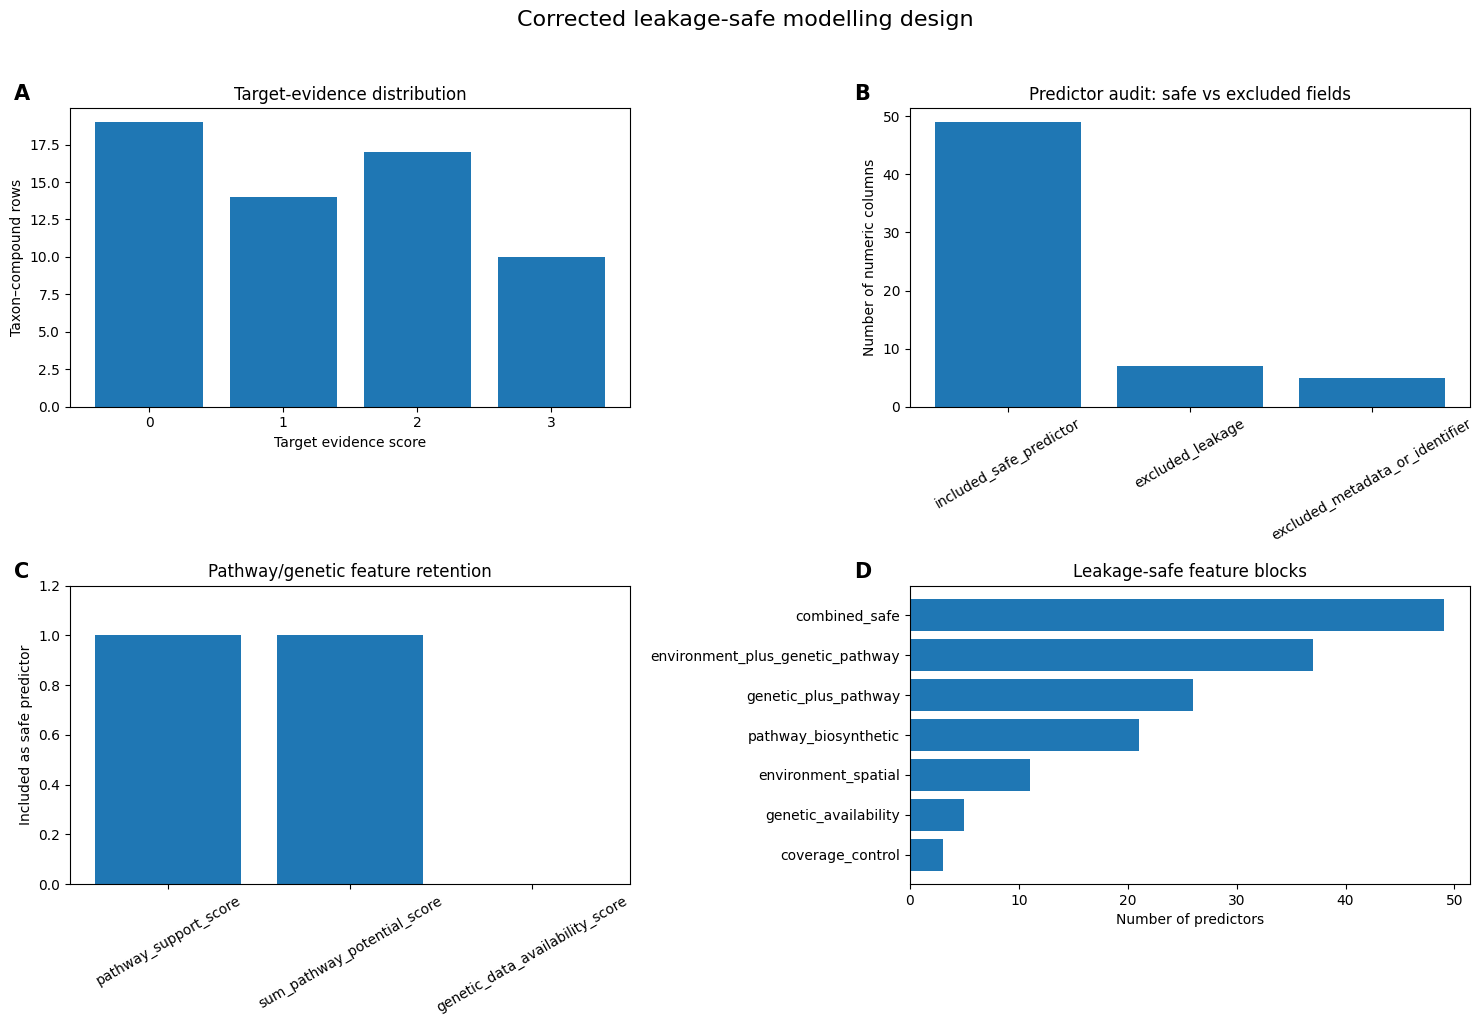

In [21]:
# ============================================================
# 15. Figure 1: Dataset design and leakage audit
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

# A: Target distribution
ax = axes[0]
counts = primary_df[CONFIG["ordinal_target_col"]].value_counts().sort_index()
ax.bar([str(x) for x in counts.index], counts.values)
ax.set_xlabel("Target evidence score")
ax.set_ylabel("Taxon–compound rows")
ax.set_title("Target-evidence distribution")
add_panel_label(ax, "A")

# B: Feature audit
ax = axes[1]
audit_counts = feature_audit_df["status"].value_counts()
ax.bar(audit_counts.index.astype(str), audit_counts.values)
ax.set_ylabel("Number of numeric columns")
ax.set_title("Predictor audit: safe vs excluded fields")
ax.tick_params(axis="x", rotation=30)
add_panel_label(ax, "B")

# C: Key biological feature inclusion check
ax = axes[2]
incl = key_feature_check.copy()
ax.bar(incl["feature"], incl["included_safe"].astype(int))
ax.set_ylim(0, 1.2)
ax.set_ylabel("Included as safe predictor")
ax.set_title("Pathway/genetic feature retention")
ax.tick_params(axis="x", rotation=30)
add_panel_label(ax, "C")

# D: Feature block sizes
ax = axes[3]
block_counts = feature_block_summary_df.set_index("feature_block")["n_features"].sort_values()
ax.barh(block_counts.index, block_counts.values)
ax.set_xlabel("Number of predictors")
ax.set_title("Leakage-safe feature blocks")
add_panel_label(ax, "D")

fig.suptitle("Corrected leakage-safe modelling design", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure1_corrected_dataset_design_and_leakage_audit_v2")
plt.show()

## 12. Figure 2 — Leakage-safe grouped performance and null controls

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure2_leakage_safe_performance_and_controls_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure2_leakage_safe_performance_and_controls_v2.pdf']


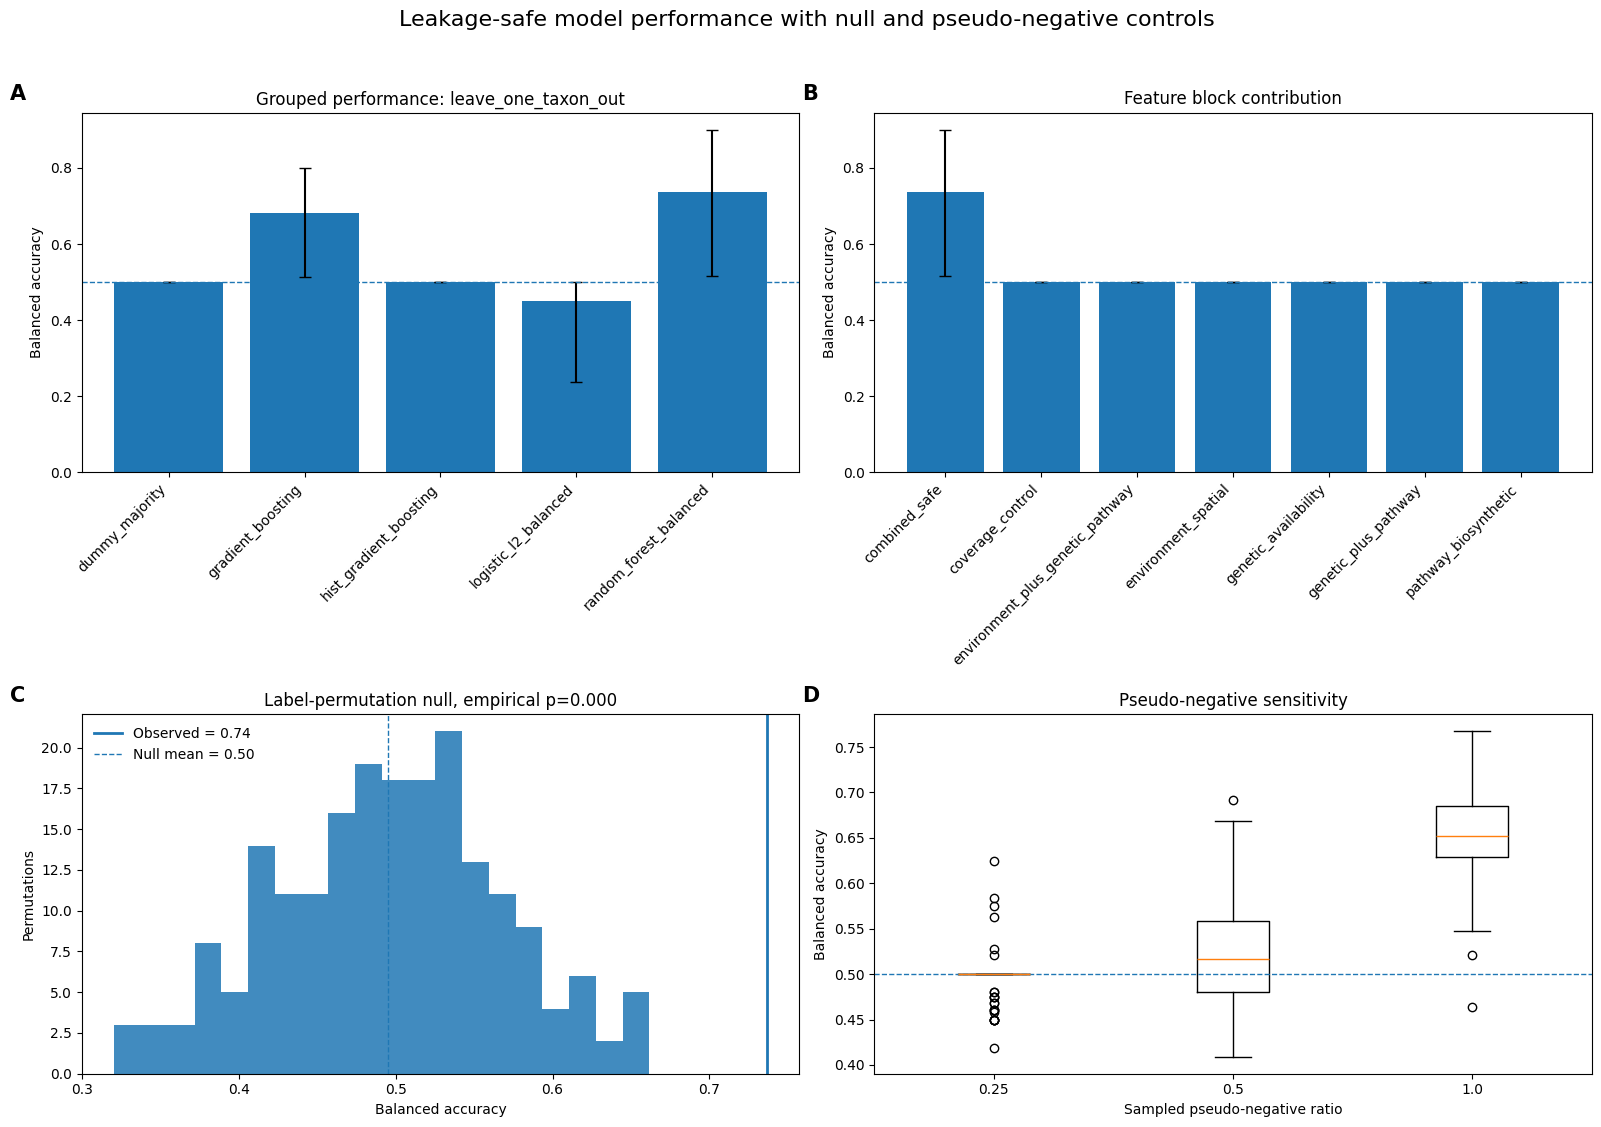

In [22]:
# ============================================================
# 16. Figure 2: Grouped performance and null controls
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.reshape(-1)

# A: Model performance under selected scheme for combined safe
ax = axes[0]
plot_df = classification_results_safe_df[
    (classification_results_safe_df["status"].eq("ok")) &
    (classification_results_safe_df["scheme"].eq(selected_scheme)) &
    (classification_results_safe_df["feature_block"].eq(selected_feature_block))
].copy()

if not plot_df.empty:
    labels, means, lows, highs = [], [], [], []
    for model, sub in plot_df.groupby("model"):
        ci = metric_ci(sub["balanced_accuracy"])
        labels.append(model)
        means.append(ci["mean"])
        lows.append(ci["mean"] - ci["ci_low"])
        highs.append(ci["ci_high"] - ci["mean"])
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=[lows, highs], capsize=4)
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Balanced accuracy")
else:
    ax.text(0.5, 0.5, "No valid folds", ha="center", va="center")
ax.set_title(f"Grouped performance: {selected_scheme}")
add_panel_label(ax, "A")

# B: Feature block comparison
ax = axes[1]
fb_df = classification_results_safe_df[
    (classification_results_safe_df["status"].eq("ok")) &
    (classification_results_safe_df["scheme"].eq(selected_scheme)) &
    (classification_results_safe_df["model"].eq(selected_model_name))
].copy()
if not fb_df.empty:
    labels, means, lows, highs = [], [], [], []
    for block, sub in fb_df.groupby("feature_block"):
        ci = metric_ci(sub["balanced_accuracy"])
        labels.append(block)
        means.append(ci["mean"])
        lows.append(ci["mean"] - ci["ci_low"])
        highs.append(ci["ci_high"] - ci["mean"])
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=[lows, highs], capsize=4)
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Balanced accuracy")
else:
    ax.text(0.5, 0.5, "No block results", ha="center", va="center")
ax.set_title("Feature block contribution")
add_panel_label(ax, "B")

# C: Label permutation null
ax = axes[2]
vals = label_permutation_df["balanced_accuracy_mean"].dropna()
if len(vals):
    ax.hist(vals, bins=20, alpha=0.85)
    ax.axvline(observed_bal_acc, linewidth=2, label=f"Observed = {observed_bal_acc:.2f}")
    ax.axvline(vals.mean(), linestyle="--", linewidth=1, label=f"Null mean = {vals.mean():.2f}")
    ax.legend(frameon=False)
ax.set_xlabel("Balanced accuracy")
ax.set_ylabel("Permutations")
ax.set_title(f"Label-permutation null, empirical p={p_value:.3f}")
add_panel_label(ax, "C")

# D: PU sensitivity
ax = axes[3]
if not pu_sensitivity_df.empty:
    ratios = sorted(pu_sensitivity_df["background_ratio"].unique())
    data = [pu_sensitivity_df[pu_sensitivity_df["background_ratio"].eq(r)]["balanced_accuracy_mean"].dropna().values for r in ratios]
    ax.boxplot(data, labels=[str(r) for r in ratios])
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_xlabel("Sampled pseudo-negative ratio")
    ax.set_ylabel("Balanced accuracy")
else:
    ax.text(0.5, 0.5, "PU sensitivity unavailable", ha="center", va="center")
ax.set_title("Pseudo-negative sensitivity")
add_panel_label(ax, "D")

fig.suptitle("Leakage-safe model performance with null and pseudo-negative controls", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure2_leakage_safe_performance_and_controls_v2")
plt.show()

## 13. Figure 3 — Safe vs leaky diagnostic comparison

This figure explicitly shows that leaky features inflate performance. It should be used as a QC/supplementary panel, not as a biological result.

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure3_safe_vs_leaky_diagnostic_comparison_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure3_safe_vs_leaky_diagnostic_comparison_v2.pdf']


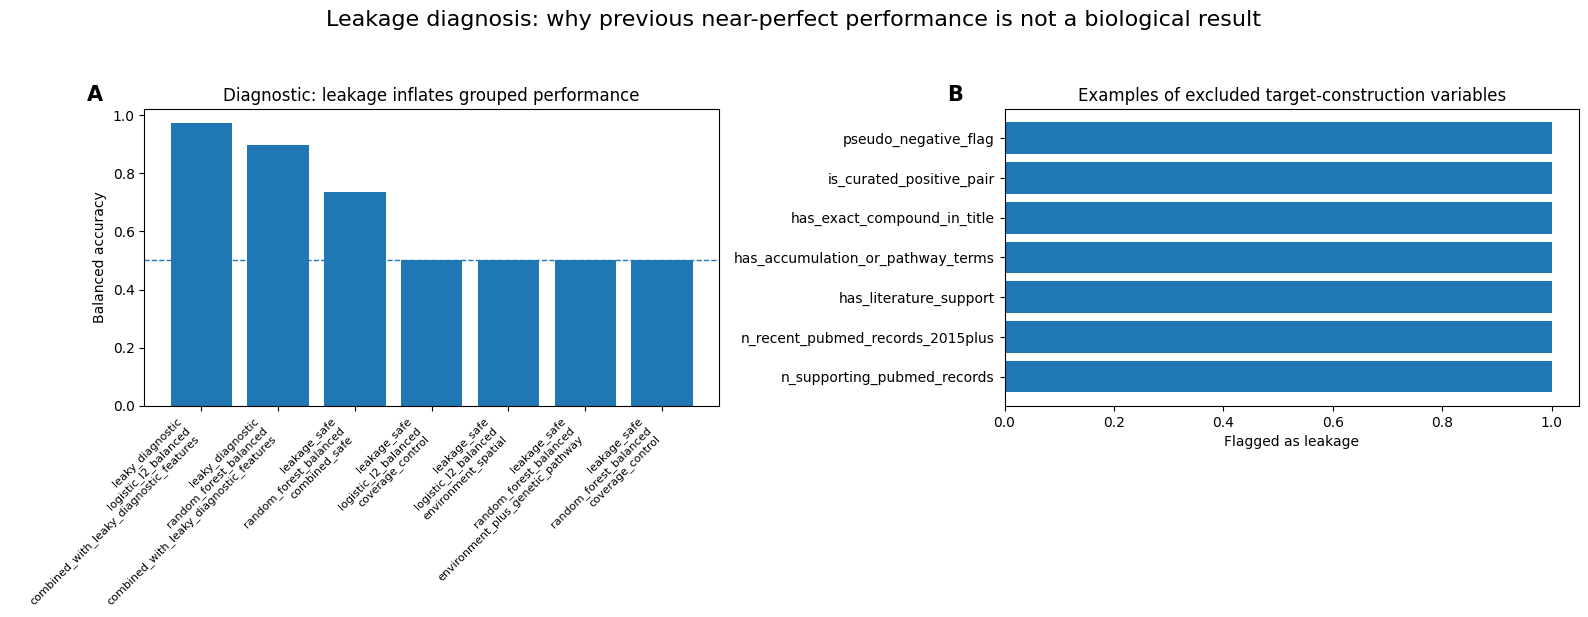

In [23]:
# ============================================================
# 17. Figure 3: Safe vs leaky diagnostic comparison
# ============================================================

safe_plot = classification_summary_safe_df.copy()
safe_plot["track"] = "leakage_safe"

leaky_plot = classification_summary_leaky_diagnostic_df.copy()
if not leaky_plot.empty:
    leaky_plot["track"] = "leaky_diagnostic"

compare_df = pd.concat([safe_plot, leaky_plot], ignore_index=True)
write_table(compare_df, DIRS["derived"] / "safe_vs_leaky_performance_comparison_v2")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A: Best safe vs leaky
ax = axes[0]
if not compare_df.empty:
    subset = compare_df[
        (compare_df["scheme"].eq(selected_scheme)) &
        (compare_df["model"].isin([selected_model_name, "logistic_l2_balanced", "random_forest_balanced"]))
    ].copy()
    if subset.empty:
        subset = compare_df.copy()
    # Best by track
    best_by_track = subset.sort_values("balanced_accuracy_mean", ascending=False).groupby("track").head(5)
    labels = best_by_track["track"] + "\n" + best_by_track["model"] + "\n" + best_by_track["feature_block"]
    ax.bar(np.arange(len(best_by_track)), best_by_track["balanced_accuracy_mean"])
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(len(best_by_track)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Balanced accuracy")
ax.set_title("Diagnostic: leakage inflates grouped performance")
add_panel_label(ax, "A")

# B: Leaky feature importance preview, if available
ax = axes[1]
if leaky_diagnostic_cols:
    leaky_preview = pd.DataFrame({"leaky_feature": leaky_diagnostic_cols[:20]})
    ax.barh(leaky_preview["leaky_feature"], np.ones(len(leaky_preview)))
    ax.set_xlabel("Flagged as leakage")
    ax.set_title("Examples of excluded target-construction variables")
else:
    ax.text(0.5, 0.5, "No leaky numeric variables detected", ha="center", va="center")
add_panel_label(ax, "B")

fig.suptitle("Leakage diagnosis: why previous near-perfect performance is not a biological result", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure3_safe_vs_leaky_diagnostic_comparison_v2")
plt.show()

## 14. Figure 4 — Leakage-safe explainability and feature relationships

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure4_leakage_safe_explainability_and_feature_relationships_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure4_leakage_safe_explainability_and_feature_relationships_v2.pdf']


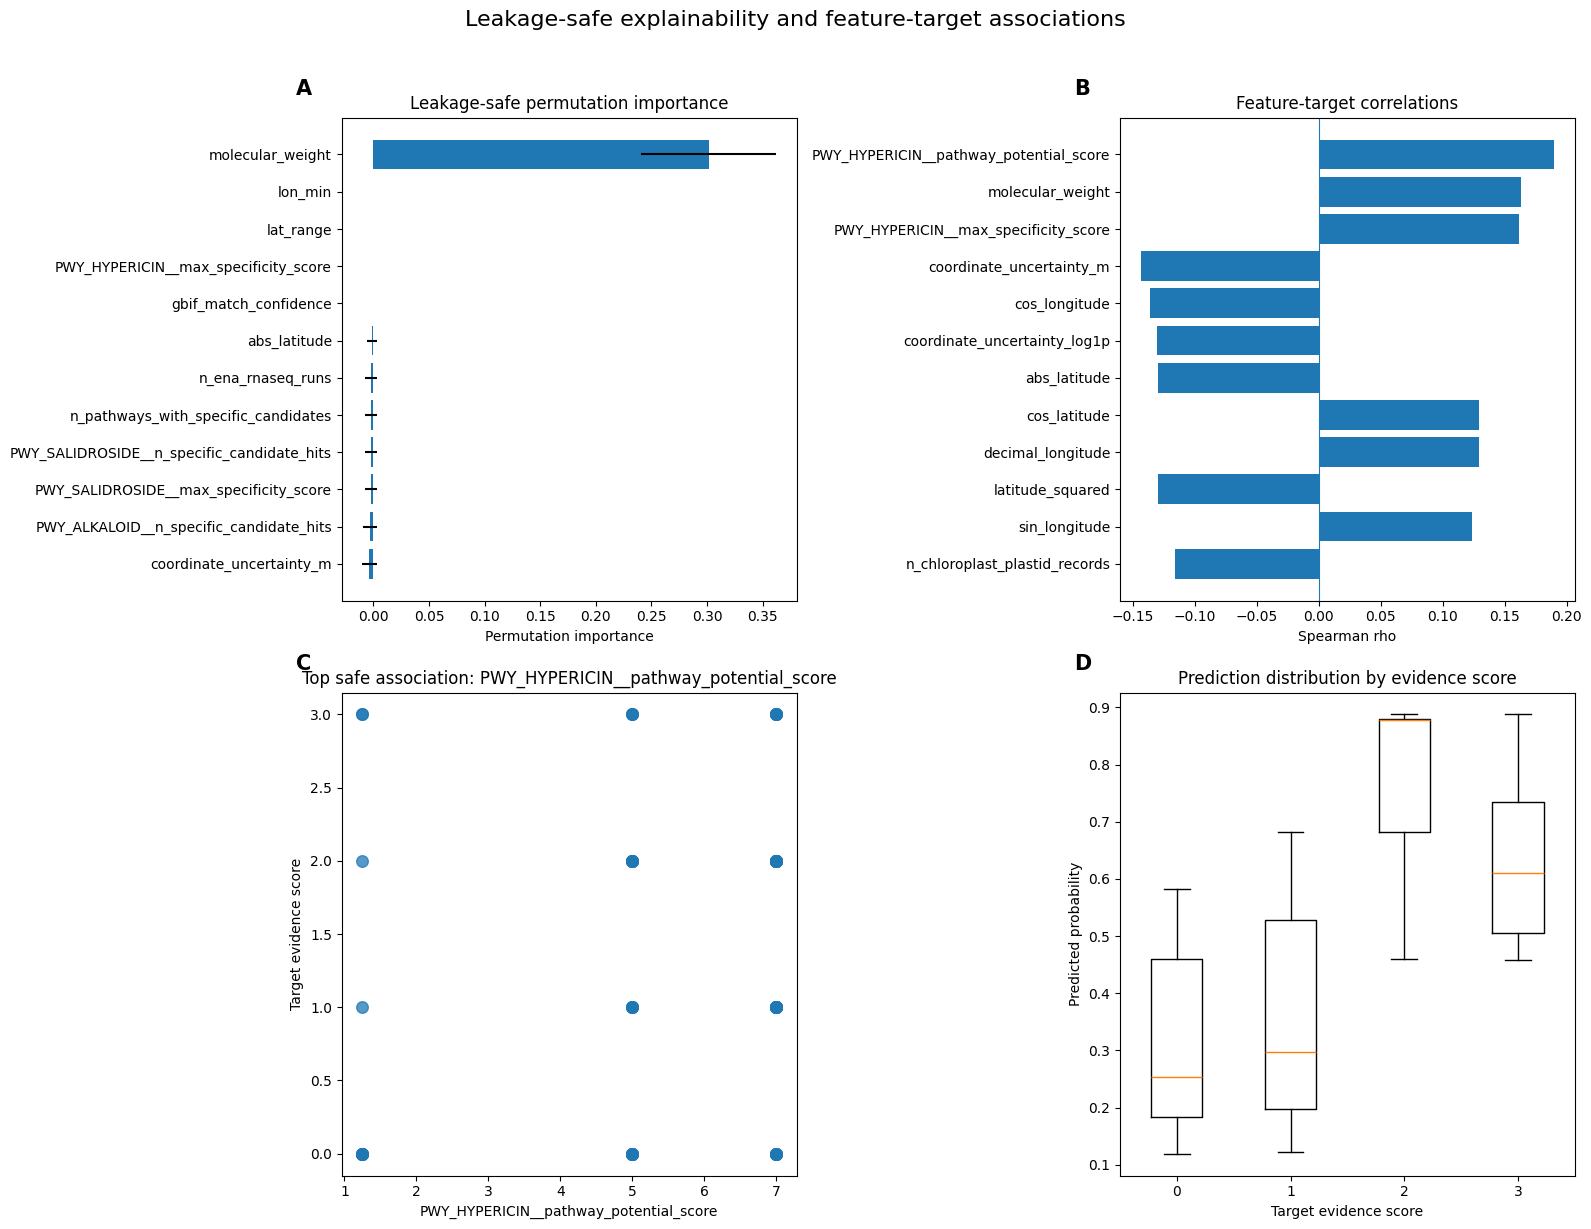

In [24]:
# ============================================================
# 18. Figure 4: Explainability and feature relationships
# ============================================================

# Feature-target Spearman correlations for safe features
corr_rows = []
for c in safe_feature_cols:
    rho = spearman_safe(primary_df[c] if c in primary_df.columns else X_safe_df[c], y_ord)
    corr_rows.append({"feature": c, "spearman_with_ordinal_target": rho})
feature_target_corr_df = pd.DataFrame(corr_rows).dropna().sort_values(
    "spearman_with_ordinal_target",
    key=lambda s: s.abs(),
    ascending=False
)
write_table(feature_target_corr_df, DIRS["derived"] / "feature_target_spearman_correlation_leakage_safe_v2")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

# A: Permutation importance
ax = axes[0]
top_perm = perm_df.head(12).iloc[::-1]
ax.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
ax.set_xlabel("Permutation importance")
ax.set_title("Leakage-safe permutation importance")
add_panel_label(ax, "A")

# B: SHAP or fallback
ax = axes[1]
if not shap_summary_df.empty:
    top_shap = shap_summary_df.head(12).iloc[::-1]
    ax.barh(top_shap["feature"], top_shap["mean_abs_shap"])
    ax.set_xlabel("Mean absolute SHAP")
    ax.set_title("SHAP summary")
else:
    top_corr = feature_target_corr_df.head(12).iloc[::-1]
    ax.barh(top_corr["feature"], top_corr["spearman_with_ordinal_target"])
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Spearman rho")
    ax.set_title("Feature-target correlations")
add_panel_label(ax, "B")

# C: Top feature scatter
ax = axes[2]
if not feature_target_corr_df.empty:
    feat = feature_target_corr_df.iloc[0]["feature"]
    x = pd.to_numeric(primary_df[feat], errors="coerce")
    ax.scatter(x, y_ord, s=70, alpha=0.75)
    ax.set_xlabel(feat)
    ax.set_ylabel("Target evidence score")
    ax.set_title(f"Top safe association: {feat}")
else:
    ax.text(0.5, 0.5, "No correlations available", ha="center", va="center")
add_panel_label(ax, "C")

# D: Prediction distribution by evidence score
ax = axes[3]
plot_df = primary_predictions_df.copy()
classes = sorted(plot_df[CONFIG["ordinal_target_col"]].dropna().unique())
data = [
    plot_df[plot_df[CONFIG["ordinal_target_col"]].eq(cls)]["predicted_probability_supported_compound_leakage_safe"].dropna().values
    for cls in classes
]
if data:
    ax.boxplot(data, labels=[str(int(c)) for c in classes])
ax.set_xlabel("Target evidence score")
ax.set_ylabel("Predicted probability")
ax.set_title("Prediction distribution by evidence score")
add_panel_label(ax, "D")

fig.suptitle("Leakage-safe explainability and feature-target associations", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure4_leakage_safe_explainability_and_feature_relationships_v2")
plt.show()

## 15. Figure 5 — PCA of leakage-safe feature space

In [25]:
# ============================================================
# 19. PCA of leakage-safe predictors
# ============================================================

pca_cols = selected_features
X_pca_raw = X_safe_df[pca_cols].copy()
X_pca = SimpleImputer(strategy="median").fit_transform(X_pca_raw)
X_pca = StandardScaler().fit_transform(X_pca)

n_components = min(5, X_pca.shape[0], X_pca.shape[1])
pca = PCA(n_components=n_components, random_state=CONFIG["random_seed"])
scores = pca.fit_transform(X_pca)

pca_scores_df = primary_df[["notebook3_primary_row_id"]].copy()
for i in range(n_components):
    pca_scores_df[f"PC{i+1}"] = scores[:, i]
pca_scores_df["target_evidence_score"] = y_ord
pca_scores_df["target_binary"] = y_bin
for c in ["taxon_id", "scientific_name", "compound_id", "compound_name", "compound_class"]:
    if c in primary_df.columns:
        pca_scores_df[c] = primary_df[c]

pca_loadings_df = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=[f"PC{i+1}" for i in range(n_components)]
).reset_index().rename(columns={"index": "feature"})

pca_explained_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

write_table(pca_scores_df, DIRS["derived"] / "pca_scores_leakage_safe_v2")
write_table(pca_loadings_df, DIRS["derived"] / "pca_loadings_leakage_safe_v2")
write_table(pca_explained_df, DIRS["derived"] / "pca_explained_variance_leakage_safe_v2")

# Correlation matrix of selected features
corr_input = X_safe_df[pca_cols].copy()
corr_input = corr_input.loc[:, corr_input.nunique(dropna=True) > 1]
corr = corr_input.corr(method="spearman").fillna(0)

if SCIPY_AVAILABLE and corr.shape[0] > 2:
    dist = 1 - np.abs(corr.values)
    np.fill_diagonal(dist, 0)
    order = leaves_list(linkage(dist, method="average"))
else:
    order = np.arange(corr.shape[0])
corr_ordered = corr.iloc[order, order]

write_table(corr.reset_index().rename(columns={"index": "feature"}), DIRS["derived"] / "selected_feature_correlation_spearman_v2")

{'tsv': '/content/notebook3_v2_leakage_safe_outputs/derived/selected_feature_correlation_spearman_v2.tsv',
 'parquet': '/content/notebook3_v2_leakage_safe_outputs/derived/selected_feature_correlation_spearman_v2.parquet'}

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure5_pca_and_correlation_leakage_safe_features_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure5_pca_and_correlation_leakage_safe_features_v2.pdf']


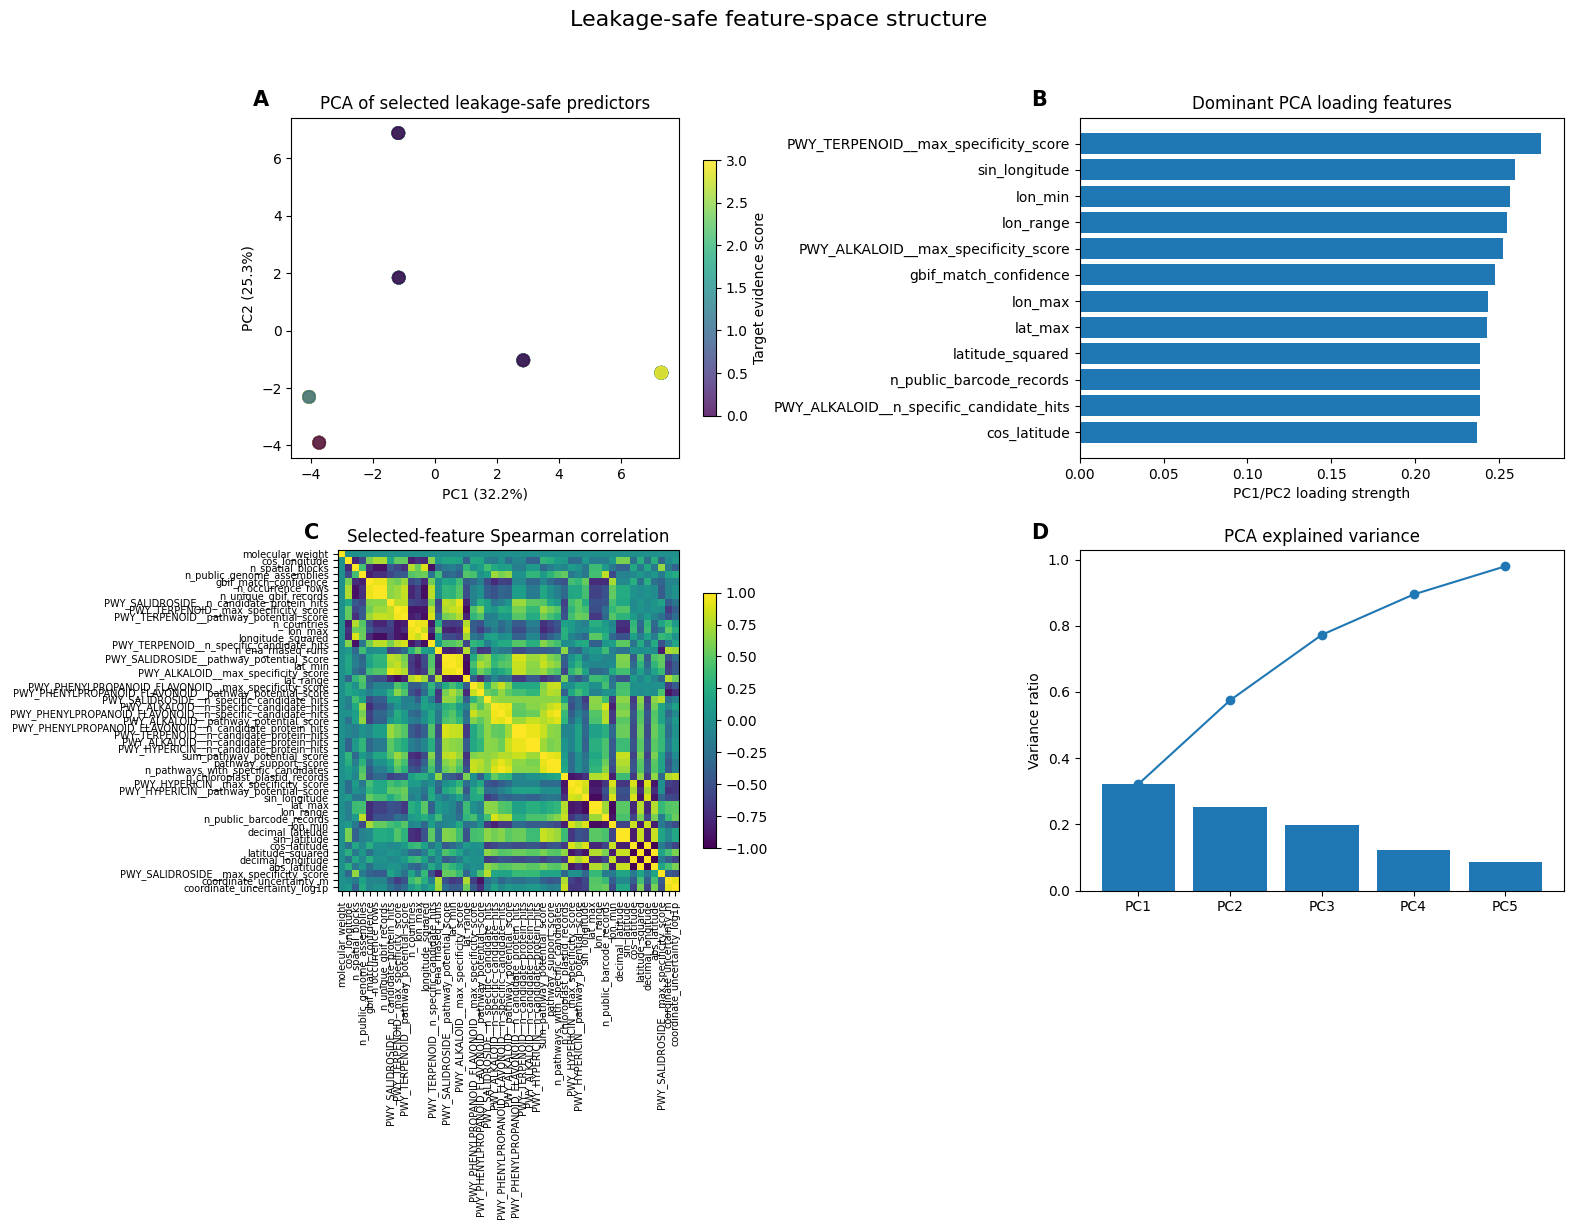

In [26]:
# ============================================================
# 20. Figure 5: PCA and correlation
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.reshape(-1)

# A: PCA score plot
ax = axes[0]
sc = ax.scatter(pca_scores_df["PC1"], pca_scores_df["PC2"], c=pca_scores_df["target_evidence_score"], s=80, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA of selected leakage-safe predictors")
fig.colorbar(sc, ax=ax, shrink=0.75, label="Target evidence score")
add_panel_label(ax, "A")

# B: PCA loadings
ax = axes[1]
load = pca_loadings_df.copy()
load["loading_strength"] = np.sqrt(load["PC1"]**2 + load["PC2"]**2)
top_load = load.sort_values("loading_strength", ascending=False).head(12).iloc[::-1]
ax.barh(top_load["feature"], top_load["loading_strength"])
ax.set_xlabel("PC1/PC2 loading strength")
ax.set_title("Dominant PCA loading features")
add_panel_label(ax, "B")

# C: Clustered correlation heatmap
ax = axes[2]
im = ax.imshow(corr_ordered.values, vmin=-1, vmax=1, interpolation="nearest")
features_ordered = corr_ordered.index.tolist()
step = max(1, len(features_ordered) // 25)
ticks = list(range(0, len(features_ordered), step))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([features_ordered[i] for i in ticks], rotation=90, fontsize=7)
ax.set_yticklabels([features_ordered[i] for i in ticks], fontsize=7)
ax.set_title("Selected-feature Spearman correlation")
fig.colorbar(im, ax=ax, shrink=0.75)
add_panel_label(ax, "C")

# D: Explained variance
ax = axes[3]
ax.bar(pca_explained_df["component"], pca_explained_df["explained_variance_ratio"])
ax.plot(pca_explained_df["component"], pca_explained_df["cumulative_explained_variance"], marker="o")
ax.set_ylabel("Variance ratio")
ax.set_title("PCA explained variance")
add_panel_label(ax, "D")

fig.suptitle("Leakage-safe feature-space structure", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure5_pca_and_correlation_leakage_safe_features_v2")
plt.show()

## 16. Figure 6 — Taxon–compound prioritization matrix

This is the safer replacement for the previous prediction heatmap. It shows model-based prioritization but explicitly uses leakage-safe fitted probabilities.

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure6_taxon_compound_prioritization_leakage_safe_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure6_taxon_compound_prioritization_leakage_safe_v2.pdf']


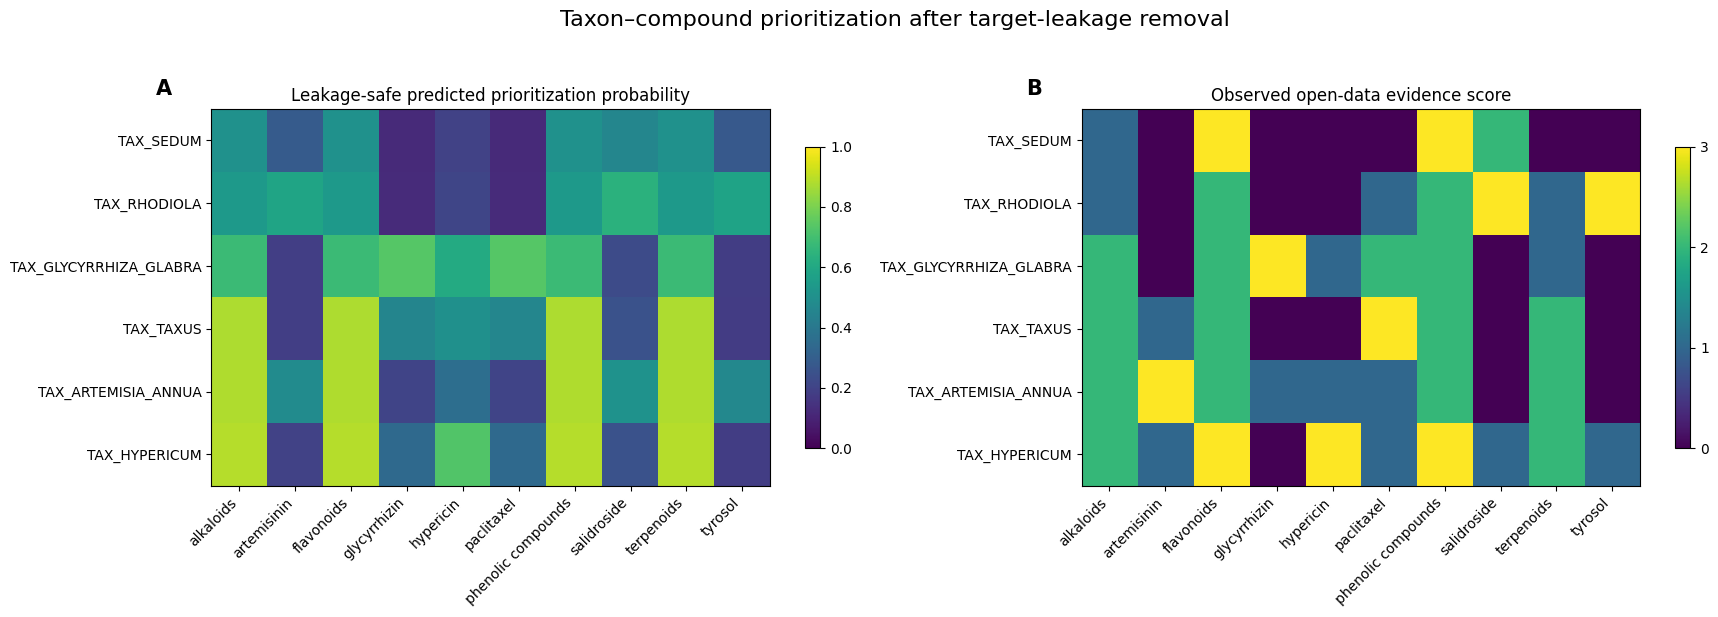

,taxon_id,compound_id,taxon_name,family,rank,priority,ml_role_taxon,open_data_ml_readiness,compound_name,compound_class,compound_record_type,record_type,compound_dictionary_status,target_evidence_class,target_type_recommendation,target_confidence_initial,target_warning,decimal_latitude,decimal_longitude,coordinate_uncertainty_m,event_date,gbif_match_confidence,gbif_filter_uncertainty_threshold_m,abs_latitude,latitude_squared,longitude_squared,sin_latitude,cos_latitude,sin_longitude,cos_longitude,coordinate_uncertainty_missing,coordinate_uncertainty_log1p,genetic_data_availability_score,pathway_support_score,n_public_barcode_records,n_chloroplast_plastid_records,n_public_genome_assemblies,n_ena_rnaseq_runs,n_pathways_with_specific_candidates,sum_pathway_potential_score,PWY_ALKALOID__n_candidate_protein_hits,PWY_HYPERICIN__n_candidate_protein_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_candidate_protein_hits,PWY_SALIDROSIDE__n_candidate_protein_hits,PWY_TERPENOID__n_candidate_protein_hits,PWY_ALKALOID__n_specific_candidate_hits,PWY_HYPERICIN__n_specific_candidate_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_specific_candidate_hits,PWY_SALIDROSIDE__n_specific_candidate_hits,PWY_TERPENOID__n_specific_candidate_hits,PWY_ALKALOID__n_broad_family_hits,PWY_HYPERICIN__n_broad_family_hits,PWY_PHENYLPROPANOID_FLAVONOID__n_broad_family_hits,PWY_SALIDROSIDE__n_broad_family_hits,PWY_TERPENOID__n_broad_family_hits,PWY_ALKALOID__max_specificity_score,PWY_HYPERICIN__max_specificity_score,PWY_PHENYLPROPANOID_FLAVONOID__max_specificity_score,PWY_SALIDROSIDE__max_specificity_score,PWY_TERPENOID__max_specificity_score,PWY_ALKALOID__pathway_potential_score,PWY_HYPERICIN__pathway_potential_score,PWY_PHENYLPROPANOID_FLAVONOID__pathway_potential_score,PWY_SALIDROSIDE__pathway_potential_score,PWY_TERPENOID__pathway_potential_score,n_supporting_pubmed_records,n_recent_pubmed_records_2015plus,has_literature_support,has_accumulation_or_pathway_terms,has_exact_compound_in_title,is_curated_positive_pair,target_evidence_score,target_label_for_open_data_classifier,pseudo_negative_flag,molecular_weight,n_occurrence_rows,n_unique_gbif_records,n_spatial_blocks,n_countries,lat_min,lat_max,lon_min,lon_max,lat_range,lon_range,taxonomic_group_id,compound_group_id,notebook3_primary_use,warning,notebook3_primary_row_id,predicted_probability_supported_compound_leakage_safe,selected_model,selected_feature_block,prediction_warning
26,TAX_HYPERICUM,CMP_TERPENOIDS,Hypericum,Hypericaceae,genus,project_core,candidate_taxon,core,terpenoids,terpenoids,compound_class,compound_class,compound_class_no_pubchem_resolution_expected,literature_supported,binary_presence_or_literature_support,low,NaN,3.7125687687661775,49.80623181622088,10.0,NaN,92,10000,37.966363866264025,1548.502674023228,12208.112336536891,0.048230882595741584,0.7754992299134054,0.016112863521471125,-0.0563864762977368,1,1.9283163778890937,6.0,10.975,3010,164,14,287,2,49.75,55,221,71,0,36,3,0,43,0,0,40,33,19,0,21,0.0,2.0,2.0,0.0,0.0,11.0,7.0,26.75,0.0,5.0,6,6,1,0,1,0,2,1,0,NaN,1159,1159,105,43,-46.90301,61.386184,-123.514542,176.878219,108.28919400000001,300.392761,Hypericaceae__TAX_HYPERICUM,terpenoids,taxon_compound_baseline,One row per taxon-compound. Use grouped CV; no...,TC_00026,0.887735,random_forest_balanced,combined_safe,In-sample fitted probabilities for prioritizat...
20,TAX_HYPERICUM,CMP_ALKALOIDS,Hypericum,Hypericaceae,genus,project_core,candidate_taxon,core,alkaloids,alkaloids,compound_class,compound_class,compound_class_no_pubchem_resolution_expected,literature_supported,candidate_for_quantitative_curation,moderate,NaN,3.7125687687661775,49.80623181622088,10.0,NaN,92,10000,37.966363866264025,1548.502674023228,12208.112336536891,0.048230882595741584,0.7754992299134054,0.016112863521471125,-0.0563864762977368,1,1.9283163778890937,6.0,10.975,3010,164,14,287,2,49.75,55,221,71,0,36,3,0,43,0,0,40,33,19,0,21,0.0,2.0,2.0,0.0,0.0,11.0,7.0,26.75,0.0,5.0,14,11,1,1,1,0,2,1,0,NaN,1159,1159,105,43,-46.90301,61.386184,-123.51454

In [27]:
# ============================================================
# 21. Figure 6: Taxon-compound prioritization matrix
# ============================================================

heat = primary_predictions_df.copy()
row_label = "scientific_name" if "scientific_name" in heat.columns else "taxon_id"
col_label = "compound_name" if "compound_name" in heat.columns else "compound_id"

prob_pivot = heat.pivot_table(
    index=row_label,
    columns=col_label,
    values="predicted_probability_supported_compound_leakage_safe",
    aggfunc="max",
    fill_value=np.nan,
)

target_pivot = heat.pivot_table(
    index=row_label,
    columns=col_label,
    values=CONFIG["ordinal_target_col"],
    aggfunc="max",
    fill_value=0,
)

prob_pivot = prob_pivot.loc[prob_pivot.max(axis=1).sort_values(ascending=True).index]
target_pivot = target_pivot.reindex(index=prob_pivot.index, columns=prob_pivot.columns)

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.55 * len(prob_pivot))))

ax = axes[0]
im = ax.imshow(prob_pivot.values, aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(prob_pivot.index)))
ax.set_yticklabels(prob_pivot.index)
ax.set_xticks(range(len(prob_pivot.columns)))
ax.set_xticklabels(prob_pivot.columns, rotation=45, ha="right")
ax.set_title("Leakage-safe predicted prioritization probability")
fig.colorbar(im, ax=ax, shrink=0.8)
add_panel_label(ax, "A")

ax = axes[1]
im2 = ax.imshow(target_pivot.values, aspect="auto", vmin=0, vmax=3)
ax.set_yticks(range(len(target_pivot.index)))
ax.set_yticklabels(target_pivot.index)
ax.set_xticks(range(len(target_pivot.columns)))
ax.set_xticklabels(target_pivot.columns, rotation=45, ha="right")
ax.set_title("Observed open-data evidence score")
fig.colorbar(im2, ax=ax, shrink=0.8, ticks=[0, 1, 2, 3])
add_panel_label(ax, "B")

fig.suptitle("Taxon–compound prioritization after target-leakage removal", fontsize=16, y=1.02)
fig.tight_layout()
save_figure(fig, "figure6_taxon_compound_prioritization_leakage_safe_v2")
plt.show()

priority_predictions_df = heat.sort_values("predicted_probability_supported_compound_leakage_safe", ascending=False)
write_table(priority_predictions_df, DIRS["derived"] / "taxon_compound_prediction_priority_leakage_safe_v2")
priority_predictions_df.head(30)

## 17. Occurrence-level spatial sensitivity

This is secondary. It should not be the main performance claim because taxon–compound labels are repeated across occurrences.

In [28]:
# ============================================================
# 22. Occurrence-level spatial sensitivity
# ============================================================

spatial_sensitivity_results_df = pd.DataFrame()

if not occurrence_sensitivity_df.empty:
    occ = occurrence_sensitivity_df.copy()

    if CONFIG["binary_target_col"] not in occ.columns and CONFIG["ordinal_target_col"] in occ.columns:
        occ[CONFIG["binary_target_col"]] = (pd.to_numeric(occ[CONFIG["ordinal_target_col"]], errors="coerce").fillna(0) >= 2).astype(int)

    if "spatial_group_id" not in occ.columns:
        if "spatial_block_id" in occ.columns:
            occ["spatial_group_id"] = occ["spatial_block_id"].astype(str)
        else:
            occ["spatial_group_id"] = "no_spatial_group"

    occ_numeric_cols = []
    for c in occ.columns:
        if c in [CONFIG["binary_target_col"], CONFIG["ordinal_target_col"]]:
            continue
        vals = pd.to_numeric(occ[c], errors="coerce")
        if vals.notna().sum() >= 3 and vals.nunique(dropna=True) > 1:
            if c not in CONFIG["explicit_leakage_columns"] and not col_contains_any(c, CONFIG["leakage_substrings"]) and not col_contains_any(c, CONFIG["identifier_or_metadata_substrings"]):
                occ_numeric_cols.append(c)

    occ_X = as_numeric_df(occ, occ_numeric_cols)
    occ_y = pd.to_numeric(occ[CONFIG["binary_target_col"]], errors="coerce").fillna(0).astype(int).values
    occ_groups = occ["spatial_group_id"].astype(str).values

    unique_groups = np.unique(occ_groups)
    if len(unique_groups) >= 5 and len(np.unique(occ_y)) == 2 and len(occ_numeric_cols) > 0:
        gkf = GroupKFold(n_splits=min(5, len(unique_groups)))
        rows = []
        model = clone(classifiers["logistic_l2_balanced"])
        for fold_id, (train_idx, test_idx) in enumerate(gkf.split(occ_X, occ_y, groups=occ_groups)):
            if len(np.unique(occ_y[train_idx])) < 2 or len(np.unique(occ_y[test_idx])) < 2:
                continue
            m = clone(model)
            m.fit(occ_X.iloc[train_idx], occ_y[train_idx])
            prob = m.predict_proba(occ_X.iloc[test_idx])[:, 1]
            pred = (prob >= 0.5).astype(int)
            rows.append({
                "fold": fold_id,
                "scheme": "spatial_group_kfold_occurrence_sensitivity",
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "balanced_accuracy": balanced_accuracy_score(occ_y[test_idx], pred),
                "f1": f1_score(occ_y[test_idx], pred, zero_division=0),
                "roc_auc": safe_roc_auc(occ_y[test_idx], prob),
                "average_precision": safe_average_precision(occ_y[test_idx], prob),
                "n_features": len(occ_numeric_cols),
            })
        spatial_sensitivity_results_df = pd.DataFrame(rows)
        write_table(spatial_sensitivity_results_df, DIRS["derived"] / "occurrence_level_spatial_sensitivity_leakage_safe_v2")
        display(spatial_sensitivity_results_df)
    else:
        print("Spatial sensitivity not feasible with current occurrence table.")
else:
    print("No occurrence-level sensitivity table available.")

,fold,scheme,n_train,n_test,balanced_accuracy,f1,roc_auc,average_precision,n_features
0,0,spatial_group_kfold_occurrence_sensitivity,56280,14070,0.655336,0.625607,0.616838,0.489000,45
1,1,spatial_group_kfold_occurrence_sensitivity,56280,14070,0.655799,0.620247,0.620411,0.495017,45
2,2,spatial_group_kfold_occurrence_sensitivity,56280,14070,0.703851,0.702464,0.692353,0.573323,45
3,3,spatial_group_kfold_occurrence_sensitivity,56280,14070,0.640679,0.614149,0.638322,0.517954,45
4,4,spatial_group_kfold_occurrence_sensitivity,56280,14070,0.637158,0.624900,0.640564,0.524142,45


## 18. Optional evidence graph summary

Graph modelling remains a future step. This graph is a framework visualization, not a primary predictive model.

Saved: ['/content/notebook3_v2_leakage_safe_outputs/figures/figure7_evidence_graph_leakage_safe_prioritization_v2.png', '/content/notebook3_v2_leakage_safe_outputs/figures/figure7_evidence_graph_leakage_safe_prioritization_v2.pdf']


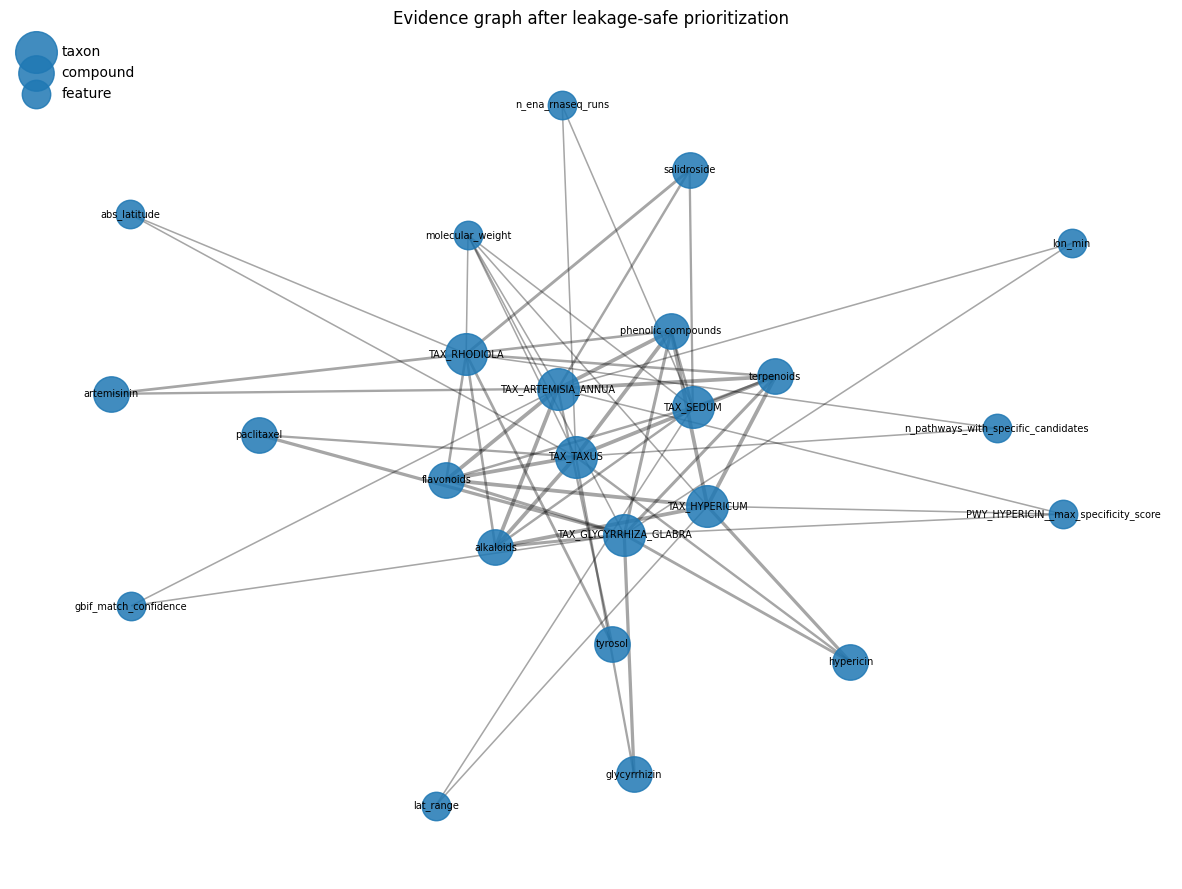

In [29]:
# ============================================================
# 23. Evidence graph visualization
# ============================================================

if NETWORKX_AVAILABLE:
    G = nx.Graph()
    for _, r in priority_predictions_df.iterrows():
        tax = r.get("taxon_id")
        comp = r.get("compound_id")
        tax_label = r.get("scientific_name", tax)
        comp_label = r.get("compound_name", comp)

        G.add_node(tax, node_type="taxon", label=tax_label)
        G.add_node(comp, node_type="compound", label=comp_label)

        prob = float(r.get("predicted_probability_supported_compound_leakage_safe", 0))
        target = int(r.get(CONFIG["ordinal_target_col"], 0))
        if prob >= 0.4 or target >= 2:
            G.add_edge(tax, comp, edge_type="taxon_compound_prediction", weight=max(prob, 0.1), target_score=target)

    for feat in perm_df.head(8)["feature"].tolist():
        G.add_node("feature:" + feat, node_type="feature", label=feat)
        if feat in primary_df.columns:
            vals = pd.to_numeric(primary_df[feat], errors="coerce")
            if vals.notna().sum() > 3:
                threshold = vals.quantile(0.75)
                for _, r in primary_df[vals >= threshold].iterrows():
                    G.add_edge(r.get("taxon_id"), "feature:" + feat, edge_type="taxon_high_feature", weight=0.25)

    pos = nx.spring_layout(G, seed=CONFIG["random_seed"], k=0.9)
    fig, ax = plt.subplots(figsize=(15, 11))
    node_types = nx.get_node_attributes(G, "node_type")
    for ntype, size in [("taxon", 900), ("compound", 650), ("feature", 420)]:
        nodes = [n for n, t in node_types.items() if t == ntype]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_size=size, alpha=0.85, label=ntype, ax=ax)
    widths = [0.5 + 2.5 * G[u][v].get("weight", 0.1) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.35, ax=ax)
    labels = nx.get_node_attributes(G, "label")
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)
    ax.set_title("Evidence graph after leakage-safe prioritization")
    ax.axis("off")
    ax.legend(frameon=False, loc="upper left")
    save_figure(fig, "figure7_evidence_graph_leakage_safe_prioritization_v2")
    plt.show()

    graph_nodes = pd.DataFrame([{"node_id": n, "node_type": node_types.get(n, ""), "label": labels.get(n, n)} for n in G.nodes()])
    graph_edges = pd.DataFrame([{"source": u, "target": v, **G[u][v]} for u, v in G.edges()])
    write_table(graph_nodes, DIRS["derived"] / "evidence_graph_nodes_leakage_safe_v2")
    write_table(graph_edges, DIRS["derived"] / "evidence_graph_edges_leakage_safe_v2")
else:
    print("networkx unavailable. Skipping graph.")

## 19. Manuscript-ready tables

In [30]:
# ============================================================
# 24. Manuscript-ready tables
# ============================================================

table1 = pd.DataFrame([
    {"item": "Primary modelling rows", "value": len(primary_df)},
    {"item": "Unique taxa", "value": primary_df["taxon_id"].nunique() if "taxon_id" in primary_df.columns else np.nan},
    {"item": "Unique compounds", "value": primary_df["compound_id"].nunique() if "compound_id" in primary_df.columns else np.nan},
    {"item": "Positive/supported binary labels", "value": int(y_bin.sum())},
    {"item": "Background/pseudo-negative labels", "value": int((y_bin == 0).sum())},
    {"item": "Safe predictor columns", "value": len(safe_feature_cols)},
    {"item": "Leaky variables excluded", "value": len(leaky_diagnostic_cols)},
    {"item": "Selected leakage-safe model", "value": selected_model_name},
    {"item": "Selected leakage-safe feature block", "value": selected_feature_block},
    {"item": "Observed grouped balanced accuracy", "value": observed_bal_acc},
    {"item": "Label-permutation empirical p-value", "value": p_value},
])
write_table(table1, DIRS["tables"] / "table1_corrected_dataset_and_model_summary_v2")

table2 = classification_summary_safe_df.sort_values("balanced_accuracy_mean", ascending=False)
write_table(table2, DIRS["tables"] / "table2_leakage_safe_grouped_classification_results_v2")

table3 = perm_df.head(30).copy()
write_table(table3, DIRS["tables"] / "table3_leakage_safe_permutation_importance_v2")

table4_cols = [c for c in [
    "taxon_id", "scientific_name", "compound_id", "compound_name", "compound_class",
    CONFIG["ordinal_target_col"], CONFIG["binary_target_col"],
    "predicted_probability_supported_compound_leakage_safe",
    "prediction_warning"
] if c in priority_predictions_df.columns]
table4 = priority_predictions_df[table4_cols].head(50)
write_table(table4, DIRS["tables"] / "table4_leakage_safe_taxon_compound_priorities_v2")

display(table1)
display(table2.head(20))
display(table3.head(20))
display(table4.head(20))

Parquet skipped for table1_corrected_dataset_and_model_summary_v2: ("Could not convert 'random_forest_balanced' with type str: tried to convert to int64", 'Conversion failed for column value with type object')


,item,value
0,Primary modelling rows,60
1,Unique taxa,6
2,Unique compounds,10
3,Positive/supported binary labels,27
4,Background/pseudo-negative labels,33
5,Safe predictor columns,49
6,Leaky variables excluded,7
7,Selected leakage-safe model,random_forest_balanced
8,Selected leakage-safe feature block,combined_safe
9,Observed grouped balanced accuracy,0.736508


,scheme,feature_block,model,n_valid_folds,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_low,balanced_accuracy_ci_high,f1_mean,f1_std,f1_ci_low,f1_ci_high,roc_auc_mean,roc_auc_std,roc_auc_ci_low,roc_auc_ci_high,average_precision_mean,average_precision_std,average_precision_ci_low,average_precision_ci_high,accuracy_mean,accuracy_std,accuracy_ci_low,accuracy_ci_high
74,leave_one_taxon_out,combined_safe,random_forest_balanced,6,0.736508,0.160347,0.514881,0.900000,0.698148,0.193782,0.451389,0.888889,0.690833,0.165535,0.468542,0.870000,0.710995,0.227025,0.445573,0.921875,0.733333,0.163299,0.5125,0.900000
71,leave_one_taxon_out,combined_safe,gradient_boosting,6,0.681746,0.116697,0.512500,0.800000,0.657191,0.142539,0.460317,0.800000,0.645952,0.151594,0.432083,0.800000,0.677963,0.209692,0.434722,0.900000,0.683333,0.116905,0.5125,0.800000
1,leave_one_compound_class_out,combined_safe,gradient_boosting,8,0.528125,0.200641,0.313125,0.873750,0.385714,0.351479,0.000000,0.776667,0.782986,0.154670,0.600000,0.980556,0.670833,0.282667,0.333333,0.991250,0.583333,0.218218,0.2250,0.833333
36,leave_one_compound_out,combined_safe,gradient_boosting,8,0.528125,0.200641,0.313125,0.873750,0.385714,0.351479,0.000000,0.776667,0.782986,0.154670,0.600000,0.980556,0.670833,0.282667,0.333333,0.991250,0.583333,0.218218,0.2250,0.833333
4,leave_one_compound_class_out,combined_safe,random_forest_balanced,8,0.512500,0.141421,0.379375,0.769375,0.344048,0.320519,0.000000,0.776667,0.565972,0.191271,0.230625,0.772917,0.479861,0.251853,0.223333,0.897222,0.562500,0.176777,0.2250,0.666667
39,leave_one_compound_out,combined_safe,random_forest_balanced,8,0.512500,0.141421,0.379375,0.769375,0.344048,0.320519,0.000000,0.776667,0.565972,0.191271,0.230625,0.772917,0.479861,0.251853,0.223333,0.897222,0.562500,0.176777,0.2250,0.666667
10,leave_one_compound_class_out,environment_plus_genetic_pathway,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333
15,leave_one_compound_class_out,environment_spatial,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333
0,leave_one_compound_class_out,combined_safe,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333
40,leave_one_compound_out,coverage_control,dummy_majority,8,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.500000,0.312500,0.187665,0.166667,0.637500,0.687500,0.187665,0.3625,0.833333


,feature,importance_mean,importance_std
38,molecular_weight,0.301549,0.060596
45,lon_min,0.000000,0.000000
47,lat_range,0.000000,0.000000
29,PWY_HYPERICIN__max_specificity_score,0.000000,0.000000
3,gbif_match_confidence,0.000000,0.000000
4,abs_latitude,-0.001364,0.004336
16,n_ena_rnaseq_runs,-0.002121,0.005257
17,n_pathways_with_specific_candidates,-0.002121,0.005257
26,PWY_SALIDROSIDE__n_specific_candidate_hits,-0.002121,0.005257
31,PWY_SALIDROSIDE__max_specificity_score,-0.002121,0.005257


,taxon_id,compound_id,compound_name,compound_class,target_evidence_score,target_label_for_open_data_classifier,predicted_probability_supported_compound_leakage_safe,prediction_warning
26,TAX_HYPERICUM,CMP_TERPENOIDS,terpenoids,terpenoids,2,1,0.887735,In-sample fitted probabilities for prioritizat...
20,TAX_HYPERICUM,CMP_ALKALOIDS,alkaloids,alkaloids,2,1,0.887735,In-sample fitted probabilities for prioritizat...
27,TAX_HYPERICUM,CMP_TOTAL_FLAVONOIDS,flavonoids,flavonoids,3,1,0.887735,In-sample fitted probabilities for prioritizat...
28,TAX_HYPERICUM,CMP_TOTAL_PHENOLICS,phenolic compounds,phenolic compounds,3,1,0.887735,In-sample fitted probabilities for prioritizat...
6,TAX_ARTEMISIA_ANNUA,CMP_TERPENOIDS,terpenoids,terpenoids,2,1,0.880532,In-sample fitted probabilities for prioritizat...
8,TAX_ARTEMISIA_ANNUA,CMP_TOTAL_PHENOLICS,phenolic compounds,phenolic compounds,2,1,0.880532,In-sample fitted probabilities for prioritizat...
7,TAX_ARTEMISIA_ANNUA,CMP_TOTAL_FLAVONOIDS,flavonoids,flavonoids,2,1,0.880532,In-sample fitted probabilities for prioritizat...
0,TAX_ARTEMISIA_ANNUA,CMP_ALKALOIDS,alkaloids,alkaloids,2,1,0.880532,In-sample fitted probabilities for prioritizat...
50,TAX_TAXUS,CMP_ALKALOIDS,alkaloids,alkaloids,2,1,0.878256,In-sample fitted probabilities for prioritizat...
56,TAX_TAXUS,CMP_TERPENOIDS,terpenoids,terpenoids,2,1,0.878256,In-sample fitted probabilities for prioritizat...


## 20. Final QC report and interpretation guidance

In [31]:
# ============================================================
# 25. Final QC report and manifest
# ============================================================

qc_lines = []
qc_lines.append("# Notebook 3 v2 QC and interpretation report")
qc_lines.append(f"Run ID: {RUN_ID}")
qc_lines.append(f"Created UTC: {CONFIG['created_utc']}")
qc_lines.append("")
qc_lines.append("## Correction summary")
qc_lines.append("- Target-construction/literature/title variables were excluded from main predictors.")
qc_lines.append("- Pathway features were retained; generic 'path' filtering was removed.")
qc_lines.append("- Leaky diagnostic results are separated from leakage-safe publishable results.")
qc_lines.append("- Label-permutation and pseudo-negative sensitivity controls were added.")
qc_lines.append("")
qc_lines.append("## Main modelling table")
qc_lines.append(f"- Primary rows: {len(primary_df)}")
qc_lines.append(f"- Unique taxa: {primary_df['taxon_id'].nunique() if 'taxon_id' in primary_df else 'NA'}")
qc_lines.append(f"- Unique compounds: {primary_df['compound_id'].nunique() if 'compound_id' in primary_df else 'NA'}")
qc_lines.append(f"- Binary positives: {int(y_bin.sum())}")
qc_lines.append(f"- Background/pseudo-negatives: {int((y_bin == 0).sum())}")
qc_lines.append(f"- Safe predictors: {len(safe_feature_cols)}")
qc_lines.append(f"- Leaky diagnostic predictors excluded: {len(leaky_diagnostic_cols)}")
qc_lines.append("")
qc_lines.append("## Selected leakage-safe baseline")
qc_lines.append(f"- Scheme: {selected_scheme}")
qc_lines.append(f"- Feature block: {selected_feature_block}")
qc_lines.append(f"- Model: {selected_model_name}")
qc_lines.append(f"- Observed balanced accuracy: {observed_bal_acc}")
qc_lines.append(f"- Label-permutation empirical p-value: {p_value}")
qc_lines.append("")
qc_lines.append("## Publishable interpretation")
qc_lines.append("The leakage-safe model can be interpreted as an open-data prioritization model only if performance remains above label-permutation and dummy baselines.")
qc_lines.append("If leakage-safe performance is weak, the publishable contribution should be framed as a reproducible open-data integration and evidence-mapping framework, not as a high-performance predictive model.")
qc_lines.append("")
qc_lines.append("## Critical limitations")
qc_lines.append("- The target is open-data medicinal compound evidence, not measured metabolite concentration.")
qc_lines.append("- Score-0 rows are pseudo-negatives/background, not confirmed absences.")
qc_lines.append("- Open genetic evidence is generally taxon-level rather than population-level.")
qc_lines.append("- Causal environmental effects require additional field, experimental, or curated concentration data.")
qc_lines.append("- Strong environmental claims require Notebook 2 full environmental extraction with WorldClim/CHELSA/SoilGrids.")

qc_path = DIRS["derived"] / "notebook3_v2_qc_and_interpretation_report.md"
qc_path.write_text("\n".join(qc_lines), encoding="utf-8")

manifest_rows = []
for path in PROJECT.rglob("*"):
    if path.is_file():
        try:
            manifest_rows.append({
                "path": str(path.relative_to(PROJECT)),
                "absolute_path": str(path),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
                "modified_utc": dt.datetime.fromtimestamp(path.stat().st_mtime, tz=dt.timezone.utc).isoformat(timespec="seconds"),
                "run_id": RUN_ID,
            })
        except Exception as e:
            print("Skipping manifest entry", path, e)

run_manifest_df = pd.DataFrame(manifest_rows).sort_values("path")
write_table(run_manifest_df, PROJECT / "run_file_manifest")

print(qc_path)
display(run_manifest_df.head(30))

/content/notebook3_v2_leakage_safe_outputs/derived/notebook3_v2_qc_and_interpretation_report.md


,path,absolute_path,bytes,sha256,modified_utc,run_id
41,derived/classification_grouped_cv_fold_results...,/content/notebook3_v2_leakage_safe_outputs/der...,12902,9a38f43b6766c761b4996b64262f00f4552d4ebaddbaff...,2026-05-14T12:11:44+00:00,20260514T120622Z
30,derived/classification_grouped_cv_fold_results...,/content/notebook3_v2_leakage_safe_outputs/der...,139668,7b70cfe4455b781cf74a2a082842775d1be3cdf4d47e9e...,2026-05-14T12:11:44+00:00,20260514T120622Z
11,derived/classification_grouped_cv_fold_results...,/content/notebook3_v2_leakage_safe_outputs/der...,10244,2db3ee3e6aab97fffd0018f06fef9779a430cf045a2d2a...,2026-05-14T12:12:03+00:00,20260514T120622Z
61,derived/classification_grouped_cv_fold_results...,/content/notebook3_v2_leakage_safe_outputs/der...,8927,fd860437e5566ad8116ebffe9bc7c522be22e72bcb22da...,2026-05-14T12:12:03+00:00,20260514T120622Z
64,derived/classification_grouped_cv_predictions_...,/content/notebook3_v2_leakage_safe_outputs/der...,20139,722b09af5682546d9896ca737de692ce1f71b09434bf9a...,2026-05-14T12:11:44+00:00,20260514T120622Z
57,derived/classification_grouped_cv_predictions_...,/content/notebook3_v2_leakage_safe_outputs/der...,575089,05f0ac432e3148312e1c56730eda48caae5ce0bde12c63...,2026-05-14T12:11:44+00:00,20260514T120622Z
19,derived/classification_grouped_cv_summary_leak...,/content/notebook3_v2_leakage_safe_outputs/der...,19185,487a6a22f457a1dfe148aa6f64d95dc59a0b7a2c6c3036...,2026-05-14T12:11:44+00:00,20260514T120622Z
49,derived/classification_grouped_cv_summary_leak...,/content/notebook3_v2_leakage_safe_outputs/der...,33030,e4231256e72d56ccac52b992d2ead3e51e9033eae97a0a...,2026-05-14T12:11:44+00:00,20260514T120622Z
36,derived/classification_grouped_cv_summary_leak...,/content/notebook3_v2_leakage_safe_outputs/der...,15800,c6707616896d662981863aaa5575d268758f1c43e84d2e...,2026-05-14T12:12:03+00:00,20260514T120622Z
66,derived/classification_grouped_cv_summary_leak...,/content/notebook3_v2_leakage_safe_outputs/der...,2151,c2f9bfba25096ae27d611b714f8f3ca8e63f7cb46f2d1c...,2026-05-14T12:12:03+00:00,20260514T120622Z


## 21. Outputs

Primary corrected outputs:

- `derived/classification_grouped_cv_summary_leakage_safe_v2.tsv`
- `derived/classification_grouped_cv_summary_leaky_diagnostic_v2.tsv`
- `derived/label_permutation_null_control_summary_v2.tsv`
- `derived/positive_unlabeled_pseudo_negative_sensitivity_v2.tsv`
- `derived/permutation_importance_leakage_safe_final_model_v2.tsv`
- `derived/primary_taxon_compound_table_with_leakage_safe_predictions_v2.tsv`
- `derived/notebook3_v2_qc_and_interpretation_report.md`

Manuscript tables:

- `tables/table1_corrected_dataset_and_model_summary_v2.tsv`
- `tables/table2_leakage_safe_grouped_classification_results_v2.tsv`
- `tables/table3_leakage_safe_permutation_importance_v2.tsv`
- `tables/table4_leakage_safe_taxon_compound_priorities_v2.tsv`

Figure panels:

- `figures/figure1_corrected_dataset_design_and_leakage_audit_v2.png/pdf`
- `figures/figure2_leakage_safe_performance_and_controls_v2.png/pdf`
- `figures/figure3_safe_vs_leaky_diagnostic_comparison_v2.png/pdf`
- `figures/figure4_leakage_safe_explainability_and_feature_relationships_v2.png/pdf`
- `figures/figure5_pca_and_correlation_leakage_safe_features_v2.png/pdf`
- `figures/figure6_taxon_compound_prioritization_leakage_safe_v2.png/pdf`
- `figures/figure7_evidence_graph_leakage_safe_prioritization_v2.png/pdf`

Recommended manuscript claim after running this notebook:

> We present a leakage-aware open-data integration framework for prioritizing medicinal wild plant taxa by combining public genetic/pathway evidence, occurrence-derived environmental space, and curated literature evidence.

Avoid claiming concentration-level prediction unless manually curated metabolite concentrations are added.